# RamanChEMBL Spectra Pipeline

This notebook is for Raman-only data loading, model inference, and evaluation.

## Phase 1

### Step 1: Read RamanChEMBL dataset and load Raman spectra

Goal of this step: prove we can read the DB and produce Raman spectra arrays from the stored ground-truth payload.

In [1]:
from pathlib import Path
import sqlite3
import zlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
ROOT = Path.cwd().resolve().parent
DB_CANDIDATES = [
    ROOT / 'ramanchembl_pipeline' / 'dataset' / 'molecule.db',
    ROOT / 'Datasets' / 'Raman-ChEMBL-part1.db',
    ROOT / 'Datasets' / 'Raman-ChEMBL-part2.db',
]

db_path = next((p for p in DB_CANDIDATES if p.exists()), None)
if db_path is None:
    raise FileNotFoundError(f'No Raman DB found in: {DB_CANDIDATES}')

print('Using DB:', db_path)

Using DB: /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/dataset/molecule.db


In [3]:
def decode_blob_payload(blob_bytes):
    """Decode RamanChEMBL blob_data payload (zlib-compressed JSON)."""
    raw = zlib.decompress(blob_bytes)
    return json.loads(raw.decode('utf-8'))

def fetch_molecule_row(con, row_id=None):
    cur = con.cursor()
    if row_id is None:
        cur.execute("SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT 1")
    else:
        cur.execute("SELECT id, SMILES, blob_data FROM molecule WHERE id = ?", (int(row_id),))
    rec = cur.fetchone()
    if rec is None:
        raise ValueError(f'No molecule row found for row_id={row_id}')
    rid, smiles, blob = rec
    payload = decode_blob_payload(blob)
    return rid, smiles, payload

def payload_to_arrays(payload):
    freq = np.asarray(payload['freq'], dtype=float)
    raman = np.asarray(payload['Raman Activ'], dtype=float)
    ir = np.asarray(payload.get('IR Inten', []), dtype=float)
    dep_p = np.asarray(payload.get('Depolar (P)', []), dtype=float)
    dep_u = np.asarray(payload.get('Depolar (U)', []), dtype=float)
    return freq, raman, ir, dep_p, dep_u

In [4]:
con = sqlite3.connect(db_path)
cur = con.cursor()
cur.execute('SELECT COUNT(*) FROM molecule')
n_rows = int(cur.fetchone()[0])
print('Total molecule rows:', n_rows)

sample_id, sample_smiles, sample_payload = fetch_molecule_row(con)
freq, raman, ir, dep_p, dep_u = payload_to_arrays(sample_payload)

print('Sample id:', sample_id)
print('SMILES:', sample_smiles)
print('payload keys:', list(sample_payload.keys()))
print('n_modes:', len(freq), 'freq[min,max]=', (float(freq.min()), float(freq.max())))
print('raman[min,max]=', (float(raman.min()), float(raman.max())))

Total molecule rows: 142032
Sample id: 1
SMILES: N#Cc1ccc2c(c1)[C@@H](N1CCCC1=O)[C@@H](C(O2)(C)C)O
payload keys: ['atoms', 'coord', 'sym', 'freq', 'red. masses', 'frc consts', 'IR Inten', 'Raman Activ', 'Depolar (P)', 'Depolar (U)', 'vib coord']
n_modes: 111 freq[min,max]= (33.20560073852539, 3528.54248046875)
raman[min,max]= (0.290800005197525, 665.0267944335938)


In [5]:
def lorentz_broadening(x0, y0, grid, sigma=12.0):
    # Same line-shape form used in capsule spectra_simulator (Lorentzian broadening).
    x0 = np.asarray(x0, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    grid = np.asarray(grid, dtype=float)
    lx = x0[:, None] - grid[None, :]
    ly = (sigma / (2.0 * np.pi)) / (lx**2 + 0.25 * sigma**2)
    return (y0[:, None] * ly).sum(axis=0)

x_axis = np.linspace(500.0, 4000.0, 3501)
raman_broadened = lorentz_broadening(freq, raman, x_axis, sigma=12.0)

df_preview = pd.DataFrame({
    'freq_cm-1': freq[:15],
    'raman_activity': raman[:15],
    'depolar_p': dep_p[:15] if len(dep_p) else np.nan,
    'depolar_u': dep_u[:15] if len(dep_u) else np.nan,
})
df_preview


,freq_cm-1,raman_activity,depolar_p,depolar_u
0,33.205601,3.3026,0.7391,0.8500
1,39.610500,2.1052,0.7265,0.8416
2,50.181198,3.1432,0.7421,0.8519
3,77.916801,0.2908,0.6285,0.7719
4,99.696198,4.6006,0.7500,0.8571
5,115.093002,2.2193,0.6029,0.7523
6,120.942299,1.2137,0.7224,0.8389
7,150.884506,0.5641,0.7415,0.8516
8,167.356400,1.2424,0.7467,0.8550
9,185.869293,0.5267,0.7362,0.8481


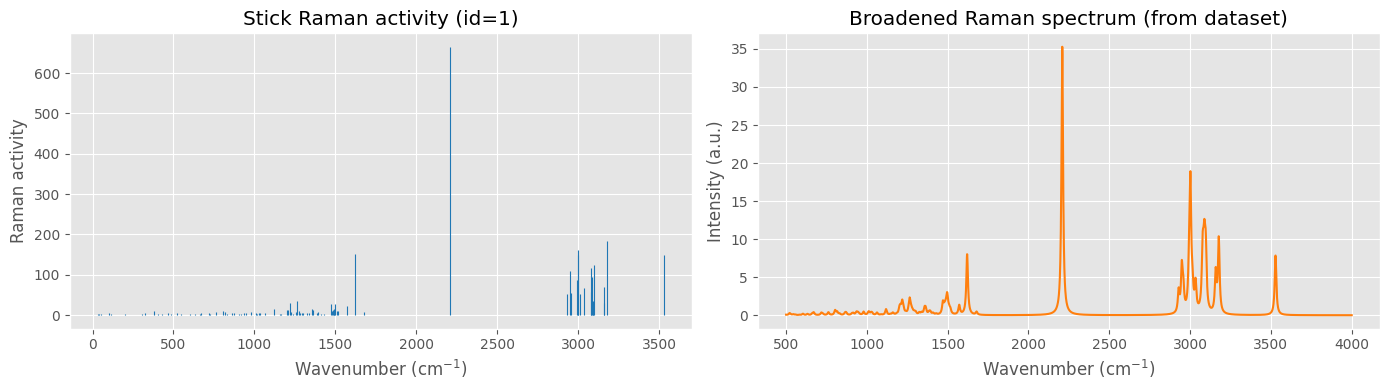

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].vlines(freq, 0, raman, color='tab:blue', lw=0.8)
ax[0].set_title(f'Stick Raman activity (id={sample_id})')
ax[0].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[0].set_ylabel('Raman activity')

ax[1].plot(x_axis, raman_broadened, color='tab:orange', lw=1.5)
ax[1].set_title('Broadened Raman spectrum (from dataset)')
ax[1].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[1].set_ylabel('Intensity (a.u.)')

plt.tight_layout()
plt.show()

In [7]:
# Optional: quick multi-row sanity read
cur = con.cursor()
cur.execute("SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT 5")
rows = cur.fetchall()
summary = []
for rid, smi, blob in rows:
    payload = decode_blob_payload(blob)
    f = np.asarray(payload['freq'], dtype=float)
    ra = np.asarray(payload['Raman Activ'], dtype=float)
    summary.append({
        'id': rid,
        'smiles': smi[:50],
        'n_modes': int(f.size),
        'freq_min': float(f.min()),
        'freq_max': float(f.max()),
        'raman_max': float(ra.max()),
    })

pd.DataFrame(summary)

,id,smiles,n_modes,freq_min,freq_max,raman_max
0,1,N#Cc1ccc2c(c1)[C@@H](N1CCCC1=O)[C@@H](C(O2)(C)C)O,111,33.205601,3528.542480,665.026794
1,2,CCC[C@@H]1C(=C(C)N=C(/C/1=C(/OC)\O)C)C(=O)OCC,123,21.583599,3484.881104,517.324219
2,3,CCO/C(=C\1/C(=NC(=C([C@H]1C)C(=O)OCCSc1ccccc1)...,147,11.388900,3488.797607,880.054077
3,4,NCCCC[C@H](C(=O)N[C@H](C(=O)CCC(=O)N1CCC[C@H]1...,228,6.417300,3572.147461,472.010895
4,5,NCCCNCCCCN(C(=O)CC(=O)NCCCCCC[N]C(=[NH2])N)C,192,13.032400,3675.128418,254.942398


In [8]:
con.close()

### Step 2: Model prediction pipeline for Raman (custom checkpoints)

This step loads custom `Hi`, `Hij`, and `polar` heads, predicts Raman from normal modes + finite-difference polarizability derivatives, and plots predicted vs dataset Raman spectrum.

In [9]:
# Quiet known non-actionable warnings from TorchScript checks and AdaLora config.
import warnings

warnings.filterwarnings(
    'ignore',
    message=r"The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`.*",
    category=UserWarning,
    module=r'torch\.jit\._check',
)

warnings.filterwarnings(
    'ignore',
    message=r'Note that `r` is not used in AdaLora and will be ignored.*',
    category=UserWarning,
    module=r'peft\.tuners\.adalora\.config',
)

print('Warning filters active for torch.jit._check and peft AdaLora config.')


Warning filters active for torch.jit._check and peft AdaLora config.


In [10]:
# Run once per fresh environment.
# Required for the custom DetaNet model interface used below.
import importlib
import subprocess
import sys


def _pip_install(spec: str) -> int:
    cmd = [sys.executable, '-m', 'pip', 'install', spec]
    print('+', ' '.join(cmd))
    return subprocess.call(cmd)


def _ensure_module(import_name: str, install_spec: str, required: bool = True):
    try:
        importlib.import_module(import_name)
        print(f'[ok] {import_name} already available')
        return True
    except Exception:
        print(f'[install] missing {import_name} -> {install_spec}')
        rc = _pip_install(install_spec)
        if rc != 0:
            if required:
                raise RuntimeError(f'Failed to install required package: {install_spec}')
            print(f'[warn] optional install failed: {install_spec}')
            return False
        importlib.import_module(import_name)
        print(f'[ok] installed {import_name}')
        return True


# Required deps.
_ensure_module('peft', 'peft>=0.13.0', required=True)
_ensure_module('torch_geometric', 'torch-geometric>=2.5.0', required=True)

# Optional native extensions. If unavailable, notebook fallbacks are used.
_ensure_module('torch_scatter', 'torch-scatter', required=False)
_ensure_module('torch_cluster', 'torch-cluster', required=False)


[ok] peft already available
[ok] torch_geometric already available
[ok] torch_scatter already available
[ok] torch_cluster already available


True

In [11]:
import sys
import types
import torch

MODEL_STACK_AVAILABLE = True
MODEL_STACK_ERROR = None

REPO_ROOT = ROOT if (ROOT / 'capsule-3259363').exists() else Path.cwd().resolve()
CAPSULE_CODE = REPO_ROOT / 'capsule-3259363' / 'code'
if str(CAPSULE_CODE) not in sys.path:
    sys.path.insert(0, str(CAPSULE_CODE))


def _install_torch_scatter_fallback_module():
    """Install a minimal torch_scatter.scatter fallback into sys.modules.

    Supports reduce='sum' and reduce='mean' for 1-D index arrays, which is
    sufficient for the paths used by DetaNet/spectra_simulator here.
    """

    def scatter(src, index, dim=0, out=None, dim_size=None, reduce='sum'):
        if reduce not in ('sum', 'mean', 'add'):
            raise NotImplementedError(f'Fallback scatter does not support reduce={reduce}')
        if not torch.is_tensor(index):
            index = torch.as_tensor(index, device=src.device)
        index = index.to(src.device, dtype=torch.long)

        if dim < 0:
            dim = src.dim() + dim
        if index.numel() == 0:
            out_shape = list(src.shape)
            out_shape[dim] = 0 if dim_size is None else dim_size
            return src.new_zeros(out_shape)

        if dim_size is None:
            dim_size = int(index.max().item()) + 1

        if out is None:
            out_shape = list(src.shape)
            out_shape[dim] = dim_size
            out = src.new_zeros(out_shape)

        view = [1] * src.dim()
        view[dim] = -1
        index_expanded = index.view(view).expand_as(src)
        out.scatter_add_(dim, index_expanded, src)

        if reduce in ('mean',):
            ones = torch.ones_like(src)
            count = src.new_zeros(out.shape)
            count.scatter_add_(dim, index_expanded, ones)
            out = out / count.clamp_min(1)

        return out

    mod = types.ModuleType('torch_scatter')
    mod.scatter = scatter
    sys.modules['torch_scatter'] = mod
    return mod


try:
    import torch_scatter  # noqa: F401
except Exception as exc:
    print('torch_scatter import failed; using fallback scatter:', repr(exc))
    _install_torch_scatter_fallback_module()

try:
    from detanet_model.detanet import DetaNet
    from detanet_model.model_loader import BASE_MODEL_CONFIG, TASK_CONFIGS
    from detanet_model.spectra_simulator import hessfreq, get_raman_act, get_raman_intensity
    from detanet_model.constant import atom_masses
    from torch_geometric.nn import radius_graph as pyg_radius_graph
except Exception as exc:
    MODEL_STACK_AVAILABLE = False
    MODEL_STACK_ERROR = exc
    print('Model stack import failed:', repr(exc))


def safe_radius_graph(pos, r, batch=None, max_num_neighbors=256):
    """Robust radius graph using PyG CPU kernel and returning edges on pos.device.

    PyG radius_graph CPU kernels currently require CPU tensors, so on MPS/CUDA
    we compute edges on CPU and move only edge_index back to the target device.
    """
    if batch is None:
        batch = torch.zeros(pos.shape[0], dtype=torch.long, device=pos.device)

    if pyg_radius_graph is not None:
        try:
            pos_cpu = pos.detach().to('cpu') if pos.device.type != 'cpu' else pos
            batch_cpu = batch.detach().to('cpu') if batch.device.type != 'cpu' else batch
            edge_cpu = pyg_radius_graph(
                x=pos_cpu,
                r=r,
                batch=batch_cpu,
                max_num_neighbors=max_num_neighbors,
            )
            return edge_cpu.to(pos.device)
        except Exception as exc:
            # Fall through to pure-torch path only if PyG fails unexpectedly.
            print('radius_graph PyG path failed, using pure-torch fallback:', repr(exc))

    edge_src = []
    edge_dst = []
    uniq_batches = torch.unique(batch)
    for b in uniq_batches:
        idx = torch.where(batch == b)[0]
        if idx.numel() <= 1:
            continue
        p = pos[idx]
        dist = torch.cdist(p, p)
        mask = (dist <= r) & (dist > 0)
        e = torch.nonzero(mask, as_tuple=False)
        if e.numel() == 0:
            continue
        edge_src.append(idx[e[:, 0]])
        edge_dst.append(idx[e[:, 1]])

    if not edge_src:
        return torch.empty((2, 0), dtype=torch.long, device=pos.device)
    return torch.stack([torch.cat(edge_src), torch.cat(edge_dst)], dim=0)


print('MODEL_STACK_AVAILABLE =', MODEL_STACK_AVAILABLE)



MODEL_STACK_AVAILABLE = True


In [12]:
WEIGHT_PATHS = {
    'Hi': [
        REPO_ROOT / 'artifacts' / 'extended_runs' / 'latest_checkpoints' / 'latest_Hi.pth',
        REPO_ROOT / 'artifacts' / 'hi' / 'prod-hi-a10080x8-clean-20260224-182057' / 'latest_Hi.pth',
    ],
    'Hij': [
        REPO_ROOT / 'artifacts' / 'hij' / 'prod-hij-a10080x8-2ep-20260224-232300' / 'latest_Hij.pth',
    ],
    'polar': [
        REPO_ROOT / 'artifacts' / 'polar' / 'polar-prod-standard-ckpt-a100x8-20260218-235335' / 'latest_polar.pth',
    ],
}


def resolve_ckpt(candidates):
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'No checkpoint found in candidates: {candidates}')


SELECTED_CKPTS = {k: resolve_ckpt(v) for k, v in WEIGHT_PATHS.items()}
print('Selected checkpoints:')
for k, v in SELECTED_CKPTS.items():
    print(' -', k, '->', v)

ARCH_CFG = dict(
    num_features=160,
    num_block=4,
    num_radial=32,
    attention_head=8,
    rc=5.0,
    dropout=0.1,
    pre_layernorm=True,
    pre_layernorm_eps=1e-5,
    elora_path='vendored',
    adalora_all_linears=True,
    adalora_scalar_heads=True,
    adalora_attention=True,
    adapter_freeze_base=True,
    adapter_unfreeze_initial=True,
)

ADALORA_CFG = dict(
    r=256,
    init_r=256,
    target_r=128,
    lora_alpha=512,
    lora_dropout=0.1,
    tinit=10,
    tfinal=20,
    total_step=1000,
    use_rslora=True,
    task_type='FEATURE_EXTRACTION',
)


def _unwrap_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            obj = obj['state_dict']
        elif 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            obj = obj['model_state_dict']
    if not isinstance(obj, dict):
        raise TypeError(f'Checkpoint payload is not a state_dict dict: {type(obj)}')

    # Handle DDP/DataParallel prefixes.
    if any(k.startswith('module.') for k in obj.keys()):
        obj = {k.replace('module.', '', 1): v for k, v in obj.items()}

    return obj


def build_custom_head(task, ckpt_path, device):
    cfg = dict(BASE_MODEL_CONFIG)
    cfg.update(TASK_CONFIGS[task])
    cfg.update(ARCH_CFG)
    cfg['adalora_config'] = dict(ADALORA_CFG)

    model = DetaNet(**cfg, device=device).to(device)
    raw_state = torch.load(ckpt_path, map_location=device)
    state = _unwrap_state_dict(raw_state)
    missing, unexpected = model.load_state_dict(state, strict=False)
    model.eval()

    print(f'[{task}] loaded {ckpt_path.name}')
    print(f'[{task}] missing={len(missing)} unexpected={len(unexpected)}')
    if len(missing):
        print(f'[{task}] first missing:', missing[:5])
    if len(unexpected):
        print(f'[{task}] first unexpected:', unexpected[:5])

    return model


Selected checkpoints:
 - Hi -> /Users/rahul/Desktop/hp-proteins-ml/artifacts/extended_runs/latest_checkpoints/latest_Hi.pth
 - Hij -> /Users/rahul/Desktop/hp-proteins-ml/artifacts/hij/prod-hij-a10080x8-2ep-20260224-232300/latest_Hij.pth
 - polar -> /Users/rahul/Desktop/hp-proteins-ml/artifacts/polar/polar-prod-standard-ckpt-a100x8-20260218-235335/latest_polar.pth


In [13]:
if not MODEL_STACK_AVAILABLE:
    raise RuntimeError(f'Model stack unavailable: {MODEL_STACK_ERROR}')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('Using device:', device)


def _edge_count_for_payload(payload, device, rc=5.0):
    atoms = np.asarray(payload['atoms'], dtype=np.int64)
    coords = np.asarray(payload['coord'], dtype=np.float32)
    z_ = torch.tensor(atoms, dtype=torch.long, device=device)
    pos_ = torch.tensor(coords, dtype=torch.float32, device=device)
    batch_ = torch.zeros(z_.shape[0], dtype=torch.long, device=device)
    edge_index_ = safe_radius_graph(pos=pos_, r=rc, batch=batch_)
    return int(edge_index_.shape[1])


def _find_inference_sample_with_edges(db_path, device, rc=5.0, max_scan=5000):
    con = sqlite3.connect(db_path)
    try:
        cur = con.cursor()
        cur.execute(
            'SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
            (int(max_scan),),
        )
        rows = cur.fetchall()
        for rid, smiles, blob in rows:
            payload = decode_blob_payload(blob)
            try:
                ecount = _edge_count_for_payload(payload, device=device, rc=rc)
            except Exception:
                continue
            if ecount > 0:
                return rid, smiles, payload, ecount
    finally:
        con.close()
    raise RuntimeError(f'No sample with non-empty radius graph found in first {max_scan} rows at rc={rc}')


# Start from previously loaded sample; switch if it has no edges at inference cutoff.
if 'sample_payload' not in globals():
    con = sqlite3.connect(db_path)
    sample_id, sample_smiles, sample_payload = fetch_molecule_row(con)
    con.close()

edge_count = _edge_count_for_payload(sample_payload, device=device, rc=5.0)
if edge_count == 0:
    print(f'Current sample id={sample_id} has no edges at rc=5.0; selecting a usable sample...')
    sample_id, sample_smiles, sample_payload, edge_count = _find_inference_sample_with_edges(
        db_path=db_path,
        device=device,
        rc=5.0,
        max_scan=5000,
    )
    print(f'Selected sample id={sample_id} with edge_count={edge_count}')
else:
    print(f'Using sample id={sample_id} with edge_count={edge_count}')

atoms = np.asarray(sample_payload['atoms'], dtype=np.int64)
coords = np.asarray(sample_payload['coord'], dtype=np.float32)
freq_gt = np.asarray(sample_payload['freq'], dtype=np.float64)
raman_gt = np.asarray(sample_payload['Raman Activ'], dtype=np.float64)

z = torch.tensor(atoms, dtype=torch.long, device=device)
pos = torch.tensor(coords, dtype=torch.float32, device=device)
batch = torch.zeros(z.shape[0], dtype=torch.long, device=device)

model_hi = build_custom_head('Hi', SELECTED_CKPTS['Hi'], device)
model_hij = build_custom_head('Hij', SELECTED_CKPTS['Hij'], device)
model_polar = build_custom_head('polar', SELECTED_CKPTS['polar'], device)


def tensor33_to_vec6(t):
    # ordering consistent with get_raman_act in spectra_simulator.py
    return torch.stack([t[0, 0], t[0, 1], t[1, 1], t[0, 2], t[1, 2], t[2, 2]], dim=0)


def hessfreq_compat(Hi, Hij, edge_index, masses, normal=False, linear=False, scale=0.965):
    """Run hessfreq with an MPS-safe CPU fallback for eigendecomposition."""
    try:
        return hessfreq(
            Hi=Hi,
            Hij=Hij,
            edge_index=edge_index,
            masses=masses,
            normal=normal,
            linear=linear,
            scale=scale,
        )
    except NotImplementedError as exc:
        msg = str(exc).lower()
        if 'linalg_eigh' not in msg and 'aten::_linalg_eigh' not in msg:
            raise
        target_device = Hi.device
        freq_cpu, modes_cpu = hessfreq(
            Hi=Hi.detach().to('cpu'),
            Hij=Hij.detach().to('cpu'),
            edge_index=edge_index.detach().to('cpu'),
            masses=masses.detach().to('cpu'),
            normal=normal,
            linear=linear,
            scale=scale,
        )
        return freq_cpu.to(target_device), modes_cpu.to(target_device)


def predict_raman_from_heads(
    z,
    pos,
    batch,
    model_hi,
    model_hij,
    model_polar,
    delta=0.005,
    rc=5.0,
    scale=0.965,
):
    edge_index = safe_radius_graph(pos=pos, r=rc, batch=batch)
    if edge_index.shape[1] == 0:
        raise RuntimeError(f'Empty edge graph at rc={rc}; cannot run DetaNet message passing')

    edge_index_model = edge_index.to(pos.device)

    # Do not wrap Hi/Hij in no_grad: these heads use coordinate gradients internally.
    Hi = model_hi(z=z, pos=pos, edge_index=edge_index_model, batch=batch)
    Hij = model_hij(z=z, pos=pos, edge_index=edge_index_model, batch=batch)

    # MPS/CUDA compatibility: align hessian inputs to Hi/Hij output device.
    hess_device = Hi.device
    edge_index_hess = edge_index_model.to(hess_device)
    masses_hess = atom_masses[z.detach().cpu()].to(hess_device)

    freq_pred, modes = hessfreq_compat(
        Hi=Hi,
        Hij=Hij,
        edge_index=edge_index_hess,
        masses=masses_hess,
        normal=True,
        linear=False,
        scale=scale,
    )
    # Keep downstream tensor ops on model input device (e.g., MPS).
    freq_pred = freq_pred.to(pos.device)
    modes = modes.to(pos.device)

    raman_tensors = []
    with torch.no_grad():
        for k in range(modes.shape[0]):
            mode_disp = modes[k]
            mode_disp = mode_disp / mode_disp.norm().clamp_min(1e-12)

            pos_plus = pos + delta * mode_disp
            pos_minus = pos - delta * mode_disp

            edge_plus = safe_radius_graph(pos=pos_plus, r=rc, batch=batch)
            edge_minus = safe_radius_graph(pos=pos_minus, r=rc, batch=batch)
            if edge_plus.shape[1] == 0:
                edge_plus = edge_index_model
            if edge_minus.shape[1] == 0:
                edge_minus = edge_index_model

            alpha_plus = model_polar(
                z=z,
                pos=pos_plus,
                edge_index=edge_plus,
                batch=batch,
            ).reshape(3, 3)
            alpha_minus = model_polar(
                z=z,
                pos=pos_minus,
                edge_index=edge_minus,
                batch=batch,
            ).reshape(3, 3)

            d_alpha = (alpha_plus - alpha_minus) / (2.0 * delta)
            raman_tensors.append(tensor33_to_vec6(d_alpha))

    raman_tensors = torch.stack(raman_tensors, dim=0)
    raman_act_pred = get_raman_act(raman_tensors)

    freq_np = freq_pred.detach().cpu().numpy()
    raman_np = raman_act_pred.detach().cpu().numpy()
    valid = np.isfinite(freq_np) & np.isfinite(raman_np) & (freq_np > 1e-8)
    freq_np = freq_np[valid]
    raman_np = raman_np[valid]
    if freq_np.size == 0:
        raise RuntimeError('No finite positive predicted modes after sanitization')

    return (
        freq_np,
        raman_np,
    )


freq_pred, raman_pred = predict_raman_from_heads(
    z=z,
    pos=pos,
    batch=batch,
    model_hi=model_hi,
    model_hij=model_hij,
    model_polar=model_polar,
    delta=0.005,
    rc=5.0,
    scale=0.965,
)

print('sample id:', sample_id)
print('GT modes:', len(freq_gt), 'Pred modes:', len(freq_pred))

Using device: mps
Using sample id=1 with edge_count=880
[Hi] loaded latest_Hi.pth
[Hi] missing=0 unexpected=0
[Hij] loaded latest_Hij.pth
[Hij] missing=0 unexpected=0
[polar] loaded latest_polar.pth
[polar] missing=0 unexpected=0
sample id: 1
GT modes: 111 Pred modes: 106


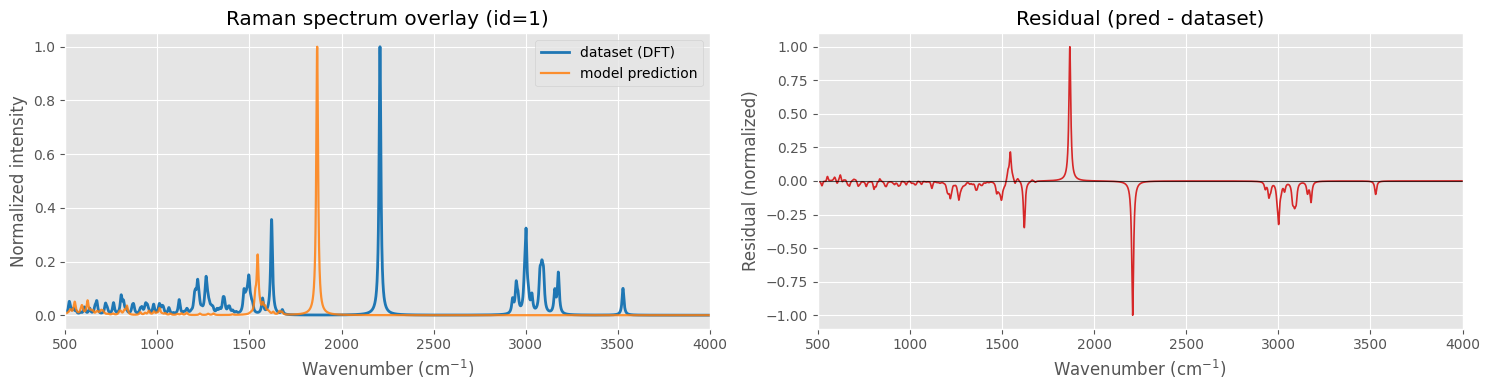

In [14]:
x_axis = np.linspace(500.0, 4000.0, 3501)

gt_act_b = lorentz_broadening(freq_gt, raman_gt, x_axis, sigma=12.0)
pred_act_b = lorentz_broadening(freq_pred, raman_pred, x_axis, sigma=12.0)

gt_spec = get_raman_intensity(
    torch.tensor(x_axis, dtype=torch.float64),
    torch.tensor(gt_act_b, dtype=torch.float64),
    temp=298,
    init_wl=532,
).detach().cpu().numpy()

pred_spec = get_raman_intensity(
    torch.tensor(x_axis, dtype=torch.float64),
    torch.tensor(pred_act_b, dtype=torch.float64),
    temp=298,
    init_wl=532,
).detach().cpu().numpy()

gt_spec_n = gt_spec / (gt_spec.max() + 1e-12)
pred_spec_n = pred_spec / (pred_spec.max() + 1e-12)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].plot(x_axis, gt_spec_n, lw=2.0, label='dataset (DFT)', color='tab:blue')
ax[0].plot(x_axis, pred_spec_n, lw=1.6, label='model prediction', color='tab:orange', alpha=0.85)
ax[0].set_xlim(500, 4000)
ax[0].set_title(f'Raman spectrum overlay (id={sample_id})')
ax[0].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[0].set_ylabel('Normalized intensity')
ax[0].legend()

resid = pred_spec_n - gt_spec_n
ax[1].plot(x_axis, resid, lw=1.2, color='tab:red')
ax[1].axhline(0.0, color='k', lw=0.8, alpha=0.7)
ax[1].set_xlim(500, 4000)
ax[1].set_title('Residual (pred - dataset)')
ax[1].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[1].set_ylabel('Residual (normalized)')

plt.tight_layout()
plt.show()

## Phase 2

### Round 2A: Analytic `dα/dR` -> `dα/dQ` (chain rule) + lightweight calibration

Goal: replace finite-difference polar derivatives with analytic gradients from the `polar` head, then calibrate frequency scale and broadening width on a small held-out subset before plotting.


In [15]:
from detanet_model.spectra_simulator import chain_rule_raman


def predict_raman_lines_round2a(
    z,
    pos,
    batch,
    model_hi,
    model_hij,
    model_polar,
    rc=5.0,
    scale=None,
):
    """Round 2A line prediction:
    1) Hi/Hij -> normal modes
    2) analytic d(alpha)/dR from polar head via autograd
    3) chain-rule projection to d(alpha)/dQ -> Raman activity lines
    """
    edge_eq = safe_radius_graph(pos=pos, r=rc, batch=batch)
    if edge_eq.shape[1] == 0:
        raise RuntimeError(f'Empty equilibrium graph at rc={rc}')

    edge_eq_model = edge_eq.to(pos.device)
    Hi = model_hi(z=z, pos=pos, edge_index=edge_eq_model, batch=batch)
    Hij = model_hij(z=z, pos=pos, edge_index=edge_eq_model, batch=batch)

    # MPS/CUDA compatibility: align hessian inputs to Hi/Hij output device.
    hess_device = Hi.device
    edge_eq_hess = edge_eq_model.to(hess_device)
    masses_hess = atom_masses[z.detach().cpu()].to(hess_device)

    freq_pred, modes = hessfreq_compat(
        Hi=Hi,
        Hij=Hij,
        edge_index=edge_eq_hess,
        masses=masses_hess,
        normal=False,
        linear=False,
        scale=scale,
    )
    freq_pred = freq_pred.to(pos.device)
    modes = modes.to(pos.device)

    pos_grad = pos.detach().clone().requires_grad_(True)
    alpha_eq = model_polar(z=z, pos=pos_grad, edge_index=edge_eq_model, batch=batch).reshape(3, 3)
    alpha6 = tensor33_to_vec6(alpha_eq)

    dp_cols = []
    for i in range(6):
        grad_i = -torch.autograd.grad(
            outputs=alpha6[i],
            inputs=pos_grad,
            retain_graph=(i < 5),
            create_graph=False,
            allow_unused=False,
        )[0]
        dp_cols.append(grad_i)

    # [n_atoms, 3, 6] cartesian derivatives of alpha tensor components.
    dp = torch.stack(dp_cols, dim=-1)

    raman_tensor = chain_rule_raman(dp=dp, modes=modes)
    raman_act_pred = get_raman_act(raman_tensor)

    freq_np = freq_pred.detach().cpu().numpy()
    raman_np = raman_act_pred.detach().cpu().numpy()

    valid = np.isfinite(freq_np) & np.isfinite(raman_np) & (freq_np > 1e-8)
    freq_np = freq_np[valid]
    raman_np = raman_np[valid]
    if freq_np.size == 0:
        raise RuntimeError('Round 2A produced no finite positive modes')

    return freq_np, raman_np


freq_pred_r2a, raman_pred_r2a = predict_raman_lines_round2a(
    z=z,
    pos=pos,
    batch=batch,
    model_hi=model_hi,
    model_hij=model_hij,
    model_polar=model_polar,
    rc=5.0,
    scale=None,
)

print('Round 2A sample id:', sample_id)
print('GT modes:', len(freq_gt), 'Round 2A modes:', len(freq_pred_r2a))




Round 2A sample id: 1
GT modes: 111 Round 2A modes: 106


In [16]:
def lines_to_norm_spectrum(freq, act, x_grid, sigma=12.0, temp=298, init_wl=532):
    freq = np.asarray(freq, dtype=np.float64)
    act = np.asarray(act, dtype=np.float64)
    valid = np.isfinite(freq) & np.isfinite(act) & (freq > 1e-8)
    freq = freq[valid]
    act = act[valid]
    if freq.size == 0:
        return np.zeros_like(x_grid, dtype=np.float64)

    act_b = lorentz_broadening(freq, act, x_grid, sigma=float(sigma))
    spec = get_raman_intensity(
        torch.tensor(x_grid, dtype=torch.float64),
        torch.tensor(act_b, dtype=torch.float64),
        temp=temp,
        init_wl=init_wl,
    ).detach().cpu().numpy()

    spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
    spec = np.clip(spec, 0.0, None)
    return spec / (spec.max() + 1e-12)


def spectrum_metrics(y_pred, y_true):
    y_pred = np.asarray(y_pred, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.float64)

    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

    if np.std(y_pred) < 1e-12 or np.std(y_true) < 1e-12:
        corr = np.nan
    else:
        corr = float(np.corrcoef(y_pred, y_true)[0, 1])

    q = 0.85
    t_pred = np.quantile(y_pred, q)
    t_true = np.quantile(y_true, q)
    mask = (y_pred >= t_pred) | (y_true >= t_true)
    if mask.sum() < 3:
        peak_rmse = np.nan
    else:
        peak_rmse = float(np.sqrt(np.mean((y_pred[mask] - y_true[mask]) ** 2)))

    return {'rmse': rmse, 'corr': corr, 'peak_rmse': peak_rmse}


def _collect_round2a_cases(db_path, device, rc=5.0, max_scan=600, max_cases=8):
    cases = []
    con = sqlite3.connect(db_path)
    try:
        cur = con.cursor()
        cur.execute(
            'SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
            (int(max_scan),),
        )
        rows = cur.fetchall()
        for rid, smiles, blob in rows:
            if len(cases) >= max_cases:
                break
            payload = decode_blob_payload(blob)

            freq_local = np.asarray(payload.get('freq', []), dtype=np.float64)
            raman_local = np.asarray(payload.get('Raman Activ', []), dtype=np.float64)
            if freq_local.size == 0 or raman_local.size == 0:
                continue

            try:
                ecount = _edge_count_for_payload(payload, device=device, rc=rc)
            except Exception:
                continue
            if ecount == 0:
                continue

            atoms_local = np.asarray(payload['atoms'], dtype=np.int64)
            coords_local = np.asarray(payload['coord'], dtype=np.float32)
            z_local = torch.tensor(atoms_local, dtype=torch.long, device=device)
            pos_local = torch.tensor(coords_local, dtype=torch.float32, device=device)
            batch_local = torch.zeros(z_local.shape[0], dtype=torch.long, device=device)

            try:
                freq_pred_local, raman_pred_local = predict_raman_lines_round2a(
                    z=z_local,
                    pos=pos_local,
                    batch=batch_local,
                    model_hi=model_hi,
                    model_hij=model_hij,
                    model_polar=model_polar,
                    rc=rc,
                    scale=None,
                )
            except Exception:
                continue

            cases.append({
                'id': int(rid),
                'smiles': smiles,
                'freq_gt': freq_local,
                'raman_gt': raman_local,
                'freq_pred_raw': freq_pred_local,
                'raman_pred': raman_pred_local,
            })
    finally:
        con.close()

    return cases


def tune_round2a(cases, x_grid, scale_grid, sigma_grid):
    rows = []
    for scale in scale_grid:
        for sigma in sigma_grid:
            metrics_all = []
            for c in cases:
                y_true = lines_to_norm_spectrum(c['freq_gt'], c['raman_gt'], x_grid, sigma=sigma)
                y_pred = lines_to_norm_spectrum(c['freq_pred_raw'] * scale, c['raman_pred'], x_grid, sigma=sigma)
                metrics_all.append(spectrum_metrics(y_pred, y_true))

            rmse_med = float(np.nanmedian([m['rmse'] for m in metrics_all]))
            peak_med = float(np.nanmedian([m['peak_rmse'] for m in metrics_all]))
            corr_med = float(np.nanmedian([m['corr'] for m in metrics_all]))

            rows.append({
                'scale': float(scale),
                'sigma': float(sigma),
                'rmse_median': rmse_med,
                'peak_rmse_median': peak_med,
                'corr_median': corr_med,
                'score': rmse_med + 0.5 * peak_med,
            })

    df = pd.DataFrame(rows).sort_values(['score', 'rmse_median', 'peak_rmse_median'], ascending=True).reset_index(drop=True)
    return df


x_axis_r2a = np.linspace(500.0, 4000.0, 3501)
round2a_cases = _collect_round2a_cases(
    db_path=db_path,
    device=device,
    rc=5.0,
    max_scan=600,
    max_cases=8,
)
print('Round 2A tuning cases:', len(round2a_cases))

if len(round2a_cases) == 0:
    raise RuntimeError('No usable Round 2A cases found for tuning')

scale_grid = np.arange(0.94, 1.01, 0.01)
sigma_grid = np.array([8.0, 10.0, 12.0, 14.0, 16.0], dtype=np.float64)

round2a_grid = tune_round2a(
    cases=round2a_cases,
    x_grid=x_axis_r2a,
    scale_grid=scale_grid,
    sigma_grid=sigma_grid,
)

round2a_best = round2a_grid.iloc[0].to_dict()
print('Round 2A best:', round2a_best)
round2a_grid.head(10)


Round 2A tuning cases: 8
Round 2A best: {'scale': 0.94, 'sigma': 8.0, 'rmse_median': 0.09048159210310469, 'peak_rmse_median': 0.1755616582004453, 'corr_median': 0.10540753481112108, 'score': 0.17826242120332736}


,scale,sigma,rmse_median,peak_rmse_median,corr_median,score
0,0.94,8.0,0.090482,0.175562,0.105408,0.178262
1,0.95,8.0,0.094256,0.182215,0.106540,0.185364
2,0.94,10.0,0.099019,0.190996,0.115820,0.194517
3,0.96,8.0,0.099444,0.194440,0.035613,0.196664
4,1.01,8.0,0.101382,0.197087,0.019141,0.199926
5,0.97,8.0,0.101929,0.196819,0.007553,0.200339
6,0.95,10.0,0.102522,0.197474,0.113806,0.201259
7,0.98,8.0,0.102437,0.197680,0.012444,0.201277
8,1.00,8.0,0.101969,0.198782,0.006051,0.201360
9,0.99,8.0,0.102294,0.198412,0.020978,0.201499


Phase 1 metrics: {'rmse': 0.06823534194385285, 'corr': -0.022010787001749473, 'peak_rmse': 0.1308757429507751}
Round 2A metrics: {'rmse': 0.06889444620398505, 'corr': 0.025356285773493286, 'peak_rmse': 0.1344121235697928}
Using tuned scale=0.940, sigma=8.0


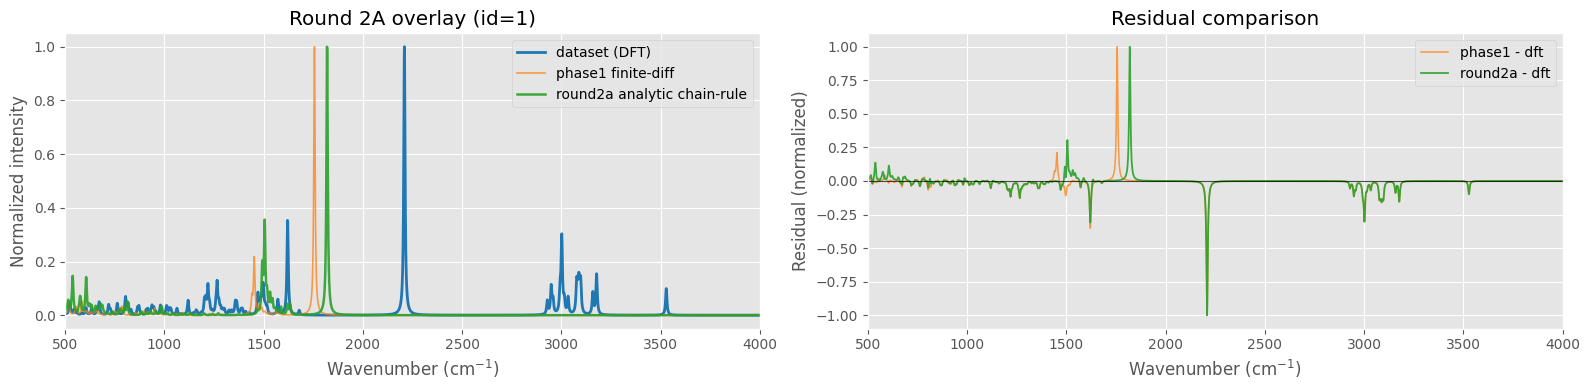

In [17]:
best_scale = float(round2a_best['scale'])
best_sigma = float(round2a_best['sigma'])

spec_gt = lines_to_norm_spectrum(freq_gt, raman_gt, x_axis_r2a, sigma=best_sigma)

# Phase 1 (finite difference) with tuned broadening for fair comparison.
spec_phase1 = lines_to_norm_spectrum(freq_pred * best_scale, raman_pred, x_axis_r2a, sigma=best_sigma)

# Round 2A (analytic d(alpha)/dR + chain rule).
spec_round2a = lines_to_norm_spectrum(freq_pred_r2a * best_scale, raman_pred_r2a, x_axis_r2a, sigma=best_sigma)

m1 = spectrum_metrics(spec_phase1, spec_gt)
m2 = spectrum_metrics(spec_round2a, spec_gt)

print('Phase 1 metrics:', m1)
print('Round 2A metrics:', m2)
print(f'Using tuned scale={best_scale:.3f}, sigma={best_sigma:.1f}')

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].plot(x_axis_r2a, spec_gt, lw=2.0, label='dataset (DFT)', color='tab:blue')
ax[0].plot(x_axis_r2a, spec_phase1, lw=1.2, label='phase1 finite-diff', color='tab:orange', alpha=0.75)
ax[0].plot(x_axis_r2a, spec_round2a, lw=1.8, label='round2a analytic chain-rule', color='tab:green', alpha=0.9)
ax[0].set_xlim(500, 4000)
ax[0].set_title(f'Round 2A overlay (id={sample_id})')
ax[0].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[0].set_ylabel('Normalized intensity')
ax[0].legend()

res_phase1 = spec_phase1 - spec_gt
res_round2a = spec_round2a - spec_gt
ax[1].plot(x_axis_r2a, res_phase1, lw=1.1, color='tab:orange', label='phase1 - dft', alpha=0.75)
ax[1].plot(x_axis_r2a, res_round2a, lw=1.3, color='tab:green', label='round2a - dft', alpha=0.9)
ax[1].axhline(0.0, color='k', lw=0.8, alpha=0.7)
ax[1].set_xlim(500, 4000)
ax[1].set_title('Residual comparison')
ax[1].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[1].set_ylabel('Residual (normalized)')
ax[1].legend()

plt.tight_layout()
plt.show()


### Phase 2B: Multi-Step FD + Richardson + Anharmonic Correction + Advanced Broadening

Round 2B upgrades the Raman reconstruction pipeline with:
- high-order (5-point) central finite differences along normal modes,
- multi-step Richardson extrapolation (O(h^4) derivative error reduction),
- stabilized blend of extrapolated and smallest-step derivative,
- anharmonic-like frequency correction term with stronger high-frequency compression,
- pseudo-Voigt broadening with frequency-dependent widths.


In [18]:
from detanet_model.constant import cm_hz, hess_t


def _repeat_edge_index(edge_index, num_nodes, repeats):
    if repeats <= 1:
        return edge_index
    offsets = torch.arange(repeats, device=edge_index.device, dtype=edge_index.dtype) * int(num_nodes)
    edge_rep = edge_index.unsqueeze(0).repeat(repeats, 1, 1)
    edge_rep = edge_rep + offsets.view(repeats, 1, 1)
    return edge_rep.permute(1, 0, 2).reshape(2, -1)


def tensor33_to_vec6_batch(t):
    # t: [B, 3, 3] -> [B, 6]
    return torch.stack([t[:, 0, 0], t[:, 0, 1], t[:, 1, 1], t[:, 0, 2], t[:, 1, 2], t[:, 2, 2]], dim=1)


def richardson_extrapolate_tensors(estimates, order=4, ratio=2.0):
    """Richardson extrapolation table over tensor-valued estimates."""
    n = len(estimates)
    if n == 1:
        return estimates[0]
    R = [[None for _ in range(n)] for _ in range(n)]
    for k in range(n):
        R[k][0] = estimates[k]
    for j in range(1, n):
        denom = (ratio ** (order * j)) - 1.0
        for k in range(j, n):
            R[k][j] = R[k][j - 1] + (R[k][j - 1] - R[k - 1][j - 1]) / denom
    return R[n - 1][n - 1]


def robust_hessfreq(Hi, Hij, edge_index, masses, normal=False, linear=False, scale=None):
    """Numerically robust Hessian diagonalization with diagonal-jitter fallback."""
    wmasses = torch.pow(masses.to(Hi.device), -0.5).repeat_interleave(3, dim=0)
    wmat = wmasses[:, None] * wmasses[None, :]

    i, j = edge_index
    dia = torch.arange(0, len(Hi), step=1, device=Hi.device, dtype=torch.long)
    hessian = torch.zeros(size=(Hi.shape[0], 3, Hi.shape[0], 3), device=Hi.device, dtype=Hi.dtype)
    hessian[j, :, i, :] = Hij
    hessian[dia, :, dia, :] = Hi
    hessian = hessian.reshape(Hi.shape[0] * 3, Hi.shape[0] * 3)
    hessian = (hessian + hessian.permute(1, 0)) / 2
    hessian = torch.nan_to_num(hessian, nan=0.0, posinf=0.0, neginf=0.0)
    hessian = hessian * wmat

    eye = torch.eye(hessian.shape[0], device=hessian.device, dtype=hessian.dtype)
    eva = evec = None
    last_exc = None
    for jitter in (0.0, 1e-10, 1e-8, 1e-6, 1e-4):
        try:
            h_try = hessian if jitter == 0.0 else (hessian + jitter * eye)
            if h_try.device.type == 'mps':
                eva_cpu, evec_cpu = torch.linalg.eigh(h_try.to('cpu'))
                eva = eva_cpu.to(h_try.device)
                evec = evec_cpu.to(h_try.device)
            else:
                eva, evec = torch.linalg.eigh(h_try)
            break
        except Exception as exc:
            last_exc = exc
            continue
    if eva is None or evec is None:
        raise RuntimeError(f'hessfreq eigendecomposition failed after jitter retries: {last_exc!r}')

    eva = eva * hess_t
    eva = torch.nan_to_num(eva, nan=0.0, posinf=0.0, neginf=0.0)
    eva = torch.clamp(eva, min=0.0)
    freq = torch.pow(eva, 0.5) / (2 * torch.pi)
    freq = freq / cm_hz
    freq = torch.nan_to_num(freq, nan=0.0, posinf=0.0, neginf=0.0)

    p = -evec.t() * wmasses
    normals = torch.norm(p, dim=1).unsqueeze(1)
    if normal:
        p = p / normals.clamp_min(1e-12)
    p = p.reshape(len(freq), -1, 3)

    if scale is not None:
        freq = freq * scale
    if linear:
        return freq[5:], p[5:]
    return freq[6:], p[6:]


def apply_anharmonic_like_correction(freq, scale=0.98, beta=0.05, high_scale=0.97, split_cm=1800.0):
    """Light empirical correction for systematic high-frequency overprediction."""
    f = np.asarray(freq, dtype=np.float64)
    f_corr = scale * f / (1.0 + beta * (f / 4000.0))
    f_corr = np.where(f >= split_cm, f_corr * high_scale, f_corr)
    return np.clip(f_corr, 1e-8, None)


def pseudo_voigt_broadening(freq, act, x_grid, sigma=12.0, gamma=8.0, eta=0.5, slope=0.0):
    freq = np.asarray(freq, dtype=np.float64)
    act = np.asarray(act, dtype=np.float64)
    x_grid = np.asarray(x_grid, dtype=np.float64)

    valid = np.isfinite(freq) & np.isfinite(act) & (freq > 1e-8)
    freq = freq[valid]
    act = act[valid]
    if freq.size == 0:
        return np.zeros_like(x_grid, dtype=np.float64)

    width_scale = 1.0 + slope * (freq / 4000.0)
    sigma_eff = np.clip(sigma * width_scale, 1e-4, None)
    gamma_eff = np.clip(gamma * width_scale, 1e-4, None)

    dx = x_grid[None, :] - freq[:, None]
    gauss = np.exp(-0.5 * (dx / sigma_eff[:, None]) ** 2) / (sigma_eff[:, None] * np.sqrt(2.0 * np.pi))
    lorentz = (gamma_eff[:, None] / np.pi) / (dx ** 2 + gamma_eff[:, None] ** 2)

    profile = (1.0 - eta) * gauss + eta * lorentz
    y = np.sum(act[:, None] * profile, axis=0)
    return y


_RAMAN_PREF_CACHE = {}


def raman_prefactor_grid(x_grid, temp=298.0, init_wl=532.0):
    key = (len(x_grid), float(x_grid[0]), float(x_grid[-1]), float(temp), float(init_wl))
    if key not in _RAMAN_PREF_CACHE:
        x_t = torch.tensor(x_grid, dtype=torch.float64)
        one = torch.ones_like(x_t)
        pref = get_raman_intensity(x_t, one, temp=temp, init_wl=init_wl).detach().cpu().numpy()
        pref = np.nan_to_num(pref, nan=0.0, posinf=0.0, neginf=0.0)
        _RAMAN_PREF_CACHE[key] = pref
    return _RAMAN_PREF_CACHE[key]


def lines_to_norm_spectrum_phase2b(
    freq,
    act,
    x_grid,
    scale=0.98,
    beta=0.05,
    high_scale=0.97,
    sigma=12.0,
    gamma=8.0,
    eta=0.5,
    slope=0.10,
    temp=298.0,
    init_wl=532.0,
):
    freq_corr = apply_anharmonic_like_correction(freq, scale=scale, beta=beta, high_scale=high_scale)
    broadened = pseudo_voigt_broadening(
        freq=freq_corr,
        act=act,
        x_grid=x_grid,
        sigma=sigma,
        gamma=gamma,
        eta=eta,
        slope=slope,
    )

    pref = raman_prefactor_grid(x_grid, temp=temp, init_wl=init_wl)
    spec = np.nan_to_num(broadened * pref, nan=0.0, posinf=0.0, neginf=0.0)
    spec = np.clip(spec, 0.0, None)
    return spec / (spec.max() + 1e-12)


def _polar_batch_for_modes(model_polar, z, pos_batch, edge_index, n_atoms):
    # pos_batch: [M, n_atoms, 3]
    m = int(pos_batch.shape[0])
    z_rep = z.repeat(m)
    batch_rep = torch.arange(m, device=z.device, dtype=torch.long).repeat_interleave(n_atoms)
    edge_rep = _repeat_edge_index(edge_index, num_nodes=n_atoms, repeats=m)
    flat = pos_batch.reshape(-1, 3)
    alpha = model_polar(z=z_rep, pos=flat, edge_index=edge_rep, batch=batch_rep)
    return alpha.reshape(m, 3, 3)


def predict_raman_lines_phase2b(
    z,
    pos,
    batch,
    model_hi,
    model_hij,
    model_polar,
    rc=5.0,
    step_sizes=(0.01, 0.005, 0.0025),
    richardson_order=4,
    richardson_blend=0.80,
    mode_chunk=32,
    show_progress=True,
):
    """Phase 2B line prediction:
      - Hi/Hij -> robust normal modes
      - 5-point central FD d(alpha)/dQ along each mode at multiple step sizes
      - Richardson extrapolation + stabilized blend
      - chunked mode processing to keep memory predictable on CPU/GPU
    """
    edge_eq = safe_radius_graph(pos=pos, r=rc, batch=batch)
    if edge_eq.shape[1] == 0:
        raise RuntimeError(f'Empty equilibrium graph at rc={rc}')

    edge_eq_model = edge_eq.to(pos.device)

    # Keep grad tracking because Hi/Hij heads internally differentiate wrt pos.
    Hi = model_hi(z=z, pos=pos, edge_index=edge_eq_model, batch=batch)
    Hij = model_hij(z=z, pos=pos, edge_index=edge_eq_model, batch=batch)

    # Device-safe hessian inputs (MPS/CUDA/CPU).
    hess_device = Hi.device
    edge_eq_hess = edge_eq_model.to(hess_device)
    masses_hess = atom_masses[z.detach().cpu()].to(hess_device)

    freq_pred, modes = robust_hessfreq(
        Hi=Hi,
        Hij=Hij,
        edge_index=edge_eq_hess,
        masses=masses_hess,
        normal=True,
        linear=False,
        scale=None,
    )
    freq_pred = freq_pred.to(pos.device)
    modes = modes.to(pos.device)

    n_modes = int(modes.shape[0])
    n_atoms = int(z.shape[0])
    if n_modes <= 0:
        raise RuntimeError('No modes returned from hessian diagonalization')

    step_sizes = tuple(sorted([float(h) for h in step_sizes], reverse=True))
    ratio = (step_sizes[0] / step_sizes[1]) if len(step_sizes) >= 2 else 2.0

    unit_modes = modes / modes.norm(dim=(1, 2), keepdim=True).clamp_min(1e-12)
    estimates = []

    if show_progress:
        print(f'Phase2B: n_modes={n_modes}, n_atoms={n_atoms}, step_sizes={step_sizes}, mode_chunk={mode_chunk}')

    with torch.inference_mode():
        for h in step_sizes:
            if show_progress:
                print(f'  step h={h:.6f}')
            deriv_chunks = []
            for start in range(0, n_modes, int(mode_chunk)):
                end = min(start + int(mode_chunk), n_modes)
                mode_block = unit_modes[start:end]
                d = mode_block * float(h)

                pos0 = pos.unsqueeze(0)
                pos_p2 = pos0 + 2.0 * d
                pos_p1 = pos0 + 1.0 * d
                pos_m1 = pos0 - 1.0 * d
                pos_m2 = pos0 - 2.0 * d

                a_p2 = _polar_batch_for_modes(model_polar, z, pos_p2, edge_eq_model, n_atoms)
                a_p1 = _polar_batch_for_modes(model_polar, z, pos_p1, edge_eq_model, n_atoms)
                a_m1 = _polar_batch_for_modes(model_polar, z, pos_m1, edge_eq_model, n_atoms)
                a_m2 = _polar_batch_for_modes(model_polar, z, pos_m2, edge_eq_model, n_atoms)

                # 5-point central derivative, O(h^4)
                d_alpha = (-a_p2 + 8.0 * a_p1 - 8.0 * a_m1 + a_m2) / (12.0 * float(h))
                deriv_chunks.append(tensor33_to_vec6_batch(d_alpha))

            estimates.append(torch.cat(deriv_chunks, dim=0))

    rich = richardson_extrapolate_tensors(estimates, order=richardson_order, ratio=ratio)
    base = estimates[-1]
    raman_tensor = richardson_blend * rich + (1.0 - richardson_blend) * base
    raman_tensor = torch.nan_to_num(raman_tensor, nan=0.0, posinf=0.0, neginf=0.0)

    spread = torch.stack(estimates, dim=0).std(dim=0, unbiased=False).mean(dim=1)
    stability_mean = float(spread.mean().item())
    stability_median = float(spread.median().item())

    raman_act_pred = get_raman_act(raman_tensor)

    freq_np = torch.nan_to_num(freq_pred, nan=0.0, posinf=0.0, neginf=0.0).detach().cpu().numpy()
    raman_np = torch.nan_to_num(raman_act_pred, nan=0.0, posinf=0.0, neginf=0.0).detach().cpu().numpy()

    valid = np.isfinite(freq_np) & np.isfinite(raman_np) & (freq_np > 1e-8)
    freq_np = freq_np[valid]
    raman_np = raman_np[valid]
    if freq_np.size == 0:
        raise RuntimeError('Phase 2B produced no finite positive modes')

    diag = {
        'n_modes_pred': int(freq_np.size),
        'stability_mean': stability_mean,
        'stability_median': stability_median,
        'richardson_ratio': float(ratio),
    }
    return freq_np, raman_np, diag





Phase2B: n_modes=111, n_atoms=39, step_sizes=(0.01, 0.005, 0.0025), mode_chunk=32
  step h=0.010000
  step h=0.005000
  step h=0.002500
Phase 2B diagnostics: {'n_modes_pred': 106, 'stability_mean': 3.903785467147827, 'stability_median': 0.007749617099761963, 'richardson_ratio': 2.0}
Phase 2B metrics: {'rmse': 0.11346286652183812, 'corr': -0.04320892789330447, 'peak_rmse': 0.21017794881419583}
Phase 1 metrics: {'rmse': 0.06823534194385285, 'corr': -0.022010787001749473, 'peak_rmse': 0.1308757429507751}
Round 2A metrics: {'rmse': 0.06889444620398505, 'corr': 0.025356285773493286, 'peak_rmse': 0.1344121235697928}


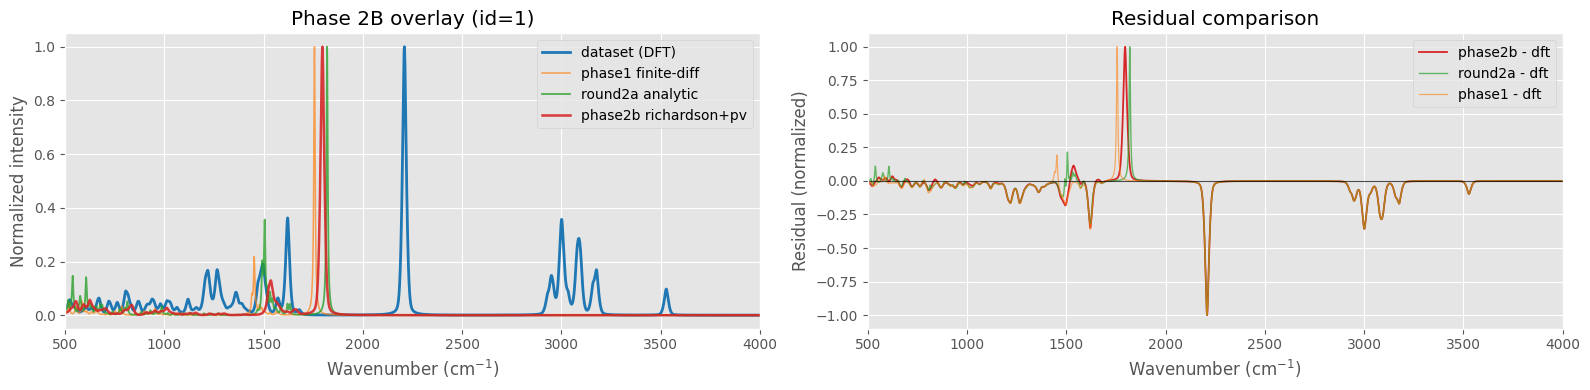

In [19]:
# Run Phase 2B on current sample.
PHASE2B_CFG = dict(
    step_sizes=(0.01, 0.005, 0.0025),
    richardson_order=4,
    richardson_blend=0.80,
    mode_chunk=32,
    scale=0.975,
    beta=0.040,
    high_scale=0.970,
    sigma=11.0,
    gamma=8.0,
    eta=0.45,
    slope=0.10,
    temp=298.0,
    init_wl=532.0,
)

freq_pred_r2b, raman_pred_r2b, r2b_diag = predict_raman_lines_phase2b(
    z=z,
    pos=pos,
    batch=batch,
    model_hi=model_hi,
    model_hij=model_hij,
    model_polar=model_polar,
    rc=5.0,
    step_sizes=PHASE2B_CFG['step_sizes'],
    richardson_order=PHASE2B_CFG['richardson_order'],
    richardson_blend=PHASE2B_CFG['richardson_blend'],
    mode_chunk=PHASE2B_CFG['mode_chunk'],
    show_progress=True,
)

# For GT, keep physical frequencies unchanged (no empirical correction).
spec_gt_r2b = lines_to_norm_spectrum_phase2b(
    freq_gt,
    raman_gt,
    x_axis_r2a,
    scale=1.0,
    beta=0.0,
    high_scale=1.0,
    sigma=PHASE2B_CFG['sigma'],
    gamma=PHASE2B_CFG['gamma'],
    eta=PHASE2B_CFG['eta'],
    slope=PHASE2B_CFG['slope'],
    temp=PHASE2B_CFG['temp'],
    init_wl=PHASE2B_CFG['init_wl'],
)

spec_round2b = lines_to_norm_spectrum_phase2b(
    freq_pred_r2b,
    raman_pred_r2b,
    x_axis_r2a,
    scale=PHASE2B_CFG['scale'],
    beta=PHASE2B_CFG['beta'],
    high_scale=PHASE2B_CFG['high_scale'],
    sigma=PHASE2B_CFG['sigma'],
    gamma=PHASE2B_CFG['gamma'],
    eta=PHASE2B_CFG['eta'],
    slope=PHASE2B_CFG['slope'],
    temp=PHASE2B_CFG['temp'],
    init_wl=PHASE2B_CFG['init_wl'],
)

m3 = spectrum_metrics(spec_round2b, spec_gt_r2b)
print('Phase 2B diagnostics:', r2b_diag)
print('Phase 2B metrics:', m3)
if 'm1' in globals():
    print('Phase 1 metrics:', m1)
if 'm2' in globals():
    print('Round 2A metrics:', m2)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
ax[0].plot(x_axis_r2a, spec_gt_r2b, lw=2.0, label='dataset (DFT)', color='tab:blue')
if 'spec_phase1' in globals():
    ax[0].plot(x_axis_r2a, spec_phase1, lw=1.1, label='phase1 finite-diff', color='tab:orange', alpha=0.7)
if 'spec_round2a' in globals():
    ax[0].plot(x_axis_r2a, spec_round2a, lw=1.3, label='round2a analytic', color='tab:green', alpha=0.8)
ax[0].plot(x_axis_r2a, spec_round2b, lw=1.8, label='phase2b richardson+pv', color='tab:red', alpha=0.9)
ax[0].set_xlim(500, 4000)
ax[0].set_title(f'Phase 2B overlay (id={sample_id})')
ax[0].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[0].set_ylabel('Normalized intensity')
ax[0].legend()

res_round2b = spec_round2b - spec_gt_r2b
ax[1].plot(x_axis_r2a, res_round2b, lw=1.3, color='tab:red', label='phase2b - dft')
if 'spec_round2a' in globals():
    ax[1].plot(x_axis_r2a, spec_round2a - spec_gt_r2b, lw=1.0, color='tab:green', alpha=0.7, label='round2a - dft')
if 'spec_phase1' in globals():
    ax[1].plot(x_axis_r2a, spec_phase1 - spec_gt_r2b, lw=0.9, color='tab:orange', alpha=0.6, label='phase1 - dft')
ax[1].axhline(0.0, color='k', lw=0.8, alpha=0.7)
ax[1].set_xlim(500, 4000)
ax[1].set_title('Residual comparison')
ax[1].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[1].set_ylabel('Residual (normalized)')
ax[1].legend()

plt.tight_layout()
plt.show()



In [20]:
# Optional: small multi-molecule check and postprocess tuning for Phase 2B.
RUN_PHASE2B_SUBSET = True


def _collect_phase2b_cases(db_path, device, max_scan=200, max_cases=4, rc=5.0):
    cases = []
    con = sqlite3.connect(db_path)
    try:
        cur = con.cursor()
        cur.execute(
            'SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
            (int(max_scan),),
        )
        rows = cur.fetchall()
        for rid, smiles, blob in rows:
            if len(cases) >= max_cases:
                break
            payload = decode_blob_payload(blob)
            freq_local = np.asarray(payload.get('freq', []), dtype=np.float64)
            raman_local = np.asarray(payload.get('Raman Activ', []), dtype=np.float64)
            if freq_local.size == 0 or raman_local.size == 0:
                continue

            try:
                if _edge_count_for_payload(payload, device=device, rc=rc) == 0:
                    continue
            except Exception:
                continue

            z_local = torch.tensor(np.asarray(payload['atoms'], dtype=np.int64), dtype=torch.long, device=device)
            pos_local = torch.tensor(np.asarray(payload['coord'], dtype=np.float32), dtype=torch.float32, device=device)
            batch_local = torch.zeros(z_local.shape[0], dtype=torch.long, device=device)

            try:
                f_pred, r_pred, _ = predict_raman_lines_phase2b(
                    z=z_local,
                    pos=pos_local,
                    batch=batch_local,
                    model_hi=model_hi,
                    model_hij=model_hij,
                    model_polar=model_polar,
                    rc=rc,
                    step_sizes=PHASE2B_CFG['step_sizes'],
                    richardson_order=PHASE2B_CFG['richardson_order'],
                    richardson_blend=PHASE2B_CFG['richardson_blend'],
                    mode_chunk=PHASE2B_CFG['mode_chunk'],
                    show_progress=False,
                )
            except Exception:
                continue

            cases.append({
                'id': int(rid),
                'smiles': smiles,
                'freq_gt': freq_local,
                'raman_gt': raman_local,
                'freq_pred': f_pred,
                'raman_pred': r_pred,
            })
    finally:
        con.close()
    return cases


def tune_phase2b_postprocess(cases, x_grid):
    # Small, bounded grid for quick local tuning.
    grid = [
        dict(scale=0.965, beta=0.030, high_scale=0.980, sigma=10.0, gamma=7.0, eta=0.40, slope=0.05),
        dict(scale=0.970, beta=0.040, high_scale=0.975, sigma=11.0, gamma=8.0, eta=0.45, slope=0.10),
        dict(scale=0.975, beta=0.050, high_scale=0.970, sigma=12.0, gamma=8.0, eta=0.50, slope=0.10),
        dict(scale=0.980, beta=0.060, high_scale=0.965, sigma=13.0, gamma=9.0, eta=0.55, slope=0.15),
    ]

    rows = []
    for cfg in grid:
        metrics_all = []
        for c in cases:
            y_true = lines_to_norm_spectrum_phase2b(
                c['freq_gt'], c['raman_gt'], x_grid,
                scale=1.0, beta=0.0, high_scale=1.0,
                sigma=cfg['sigma'], gamma=cfg['gamma'], eta=cfg['eta'], slope=cfg['slope'],
                temp=PHASE2B_CFG['temp'], init_wl=PHASE2B_CFG['init_wl'],
            )
            y_pred = lines_to_norm_spectrum_phase2b(
                c['freq_pred'], c['raman_pred'], x_grid,
                scale=cfg['scale'], beta=cfg['beta'], high_scale=cfg['high_scale'],
                sigma=cfg['sigma'], gamma=cfg['gamma'], eta=cfg['eta'], slope=cfg['slope'],
                temp=PHASE2B_CFG['temp'], init_wl=PHASE2B_CFG['init_wl'],
            )
            metrics_all.append(spectrum_metrics(y_pred, y_true))

        rmse_med = float(np.nanmedian([m['rmse'] for m in metrics_all]))
        peak_med = float(np.nanmedian([m['peak_rmse'] for m in metrics_all]))
        corr_med = float(np.nanmedian([m['corr'] for m in metrics_all]))

        rows.append({
            **cfg,
            'rmse_median': rmse_med,
            'peak_rmse_median': peak_med,
            'corr_median': corr_med,
            'score': rmse_med + 0.5 * peak_med,
        })

    return pd.DataFrame(rows).sort_values(['score', 'rmse_median', 'peak_rmse_median'], ascending=True).reset_index(drop=True)


if RUN_PHASE2B_SUBSET:
    cases = _collect_phase2b_cases(db_path=db_path, device=device, max_scan=200, max_cases=4, rc=5.0)
    print('Phase 2B subset cases:', len(cases), 'ids=', [c['id'] for c in cases])

    if len(cases):
        df_phase2b_tune = tune_phase2b_postprocess(cases, x_axis_r2a)
        display(df_phase2b_tune)
        if len(df_phase2b_tune):
            best_cfg = df_phase2b_tune.iloc[0].to_dict()
            print('Best Phase 2B postprocess cfg:', best_cfg)
else:
    print('Set RUN_PHASE2B_SUBSET=True to run quick Phase 2B multi-molecule tuning.')


Phase 2B subset cases: 4 ids= [1, 2, 3, 4]


,scale,beta,high_scale,sigma,gamma,eta,slope,rmse_median,peak_rmse_median,corr_median,score
0,0.965,0.03,0.980,10.0,7.0,0.40,0.05,0.101979,0.196568,0.236223,0.200263
1,0.970,0.04,0.975,11.0,8.0,0.45,0.10,0.109803,0.209681,0.230263,0.214644
2,0.975,0.05,0.970,12.0,8.0,0.50,0.10,0.111968,0.213279,0.215742,0.218607
3,0.980,0.06,0.965,13.0,9.0,0.55,0.15,0.119293,0.226699,0.214692,0.232642


Best Phase 2B postprocess cfg: {'scale': 0.965, 'beta': 0.03, 'high_scale': 0.98, 'sigma': 10.0, 'gamma': 7.0, 'eta': 0.4, 'slope': 0.05, 'rmse_median': 0.10197946972273558, 'peak_rmse_median': 0.1965676591829118, 'corr_median': 0.23622290667360404, 'score': 0.20026329931419148}


,id,smiles,n_atoms,n_modes_pred,rmse,corr,peak_rmse,frechet
0,210,OCCCC/N=C/c1c2ccccc2nc2-c3n(Cc12)c(=O)c1c(c3)[...,58,157,0.092816,0.575379,0.181598,0.786783
1,120,ON1CCc2c(C1=O)cccc2,21,56,0.206030,0.174411,0.395775,0.972249
2,152,COc1ccc(cc1)S(=O)(=O)N(c1c(C)cccc1C(=O)NO)Cc1c...,63,163,0.194465,0.065571,0.372230,0.978413
3,565,COc1cccc2c1CCC[C@H]2CN(CCc1ccc2c(c1)ocn2)C,52,145,0.168289,0.304184,0.326526,0.983184
4,405,CCCCCCCCCCCCc1ccnc(c1)c1nccc(c1)CCCCCCCCCCCC,92,267,0.174522,0.284760,0.339276,0.995385
5,390,NCCCC[C@@H](C(=O)N[C@H](C(=O)N[C@H](C(=O)N[C@H...,97,270,0.171074,-0.038025,0.318010,0.999988
6,290,OC(=O)[C@@H]1CN(C(=O)N1C(=O)[C@@H](N)C)C,28,78,0.142359,0.083268,0.273968,0.999992
7,484,COc1ccc(cc1O)C[C@H]([C@H](Cc1ccc(c(c1)O)OC)C)C,50,134,0.204837,-0.004435,0.386124,0.999993


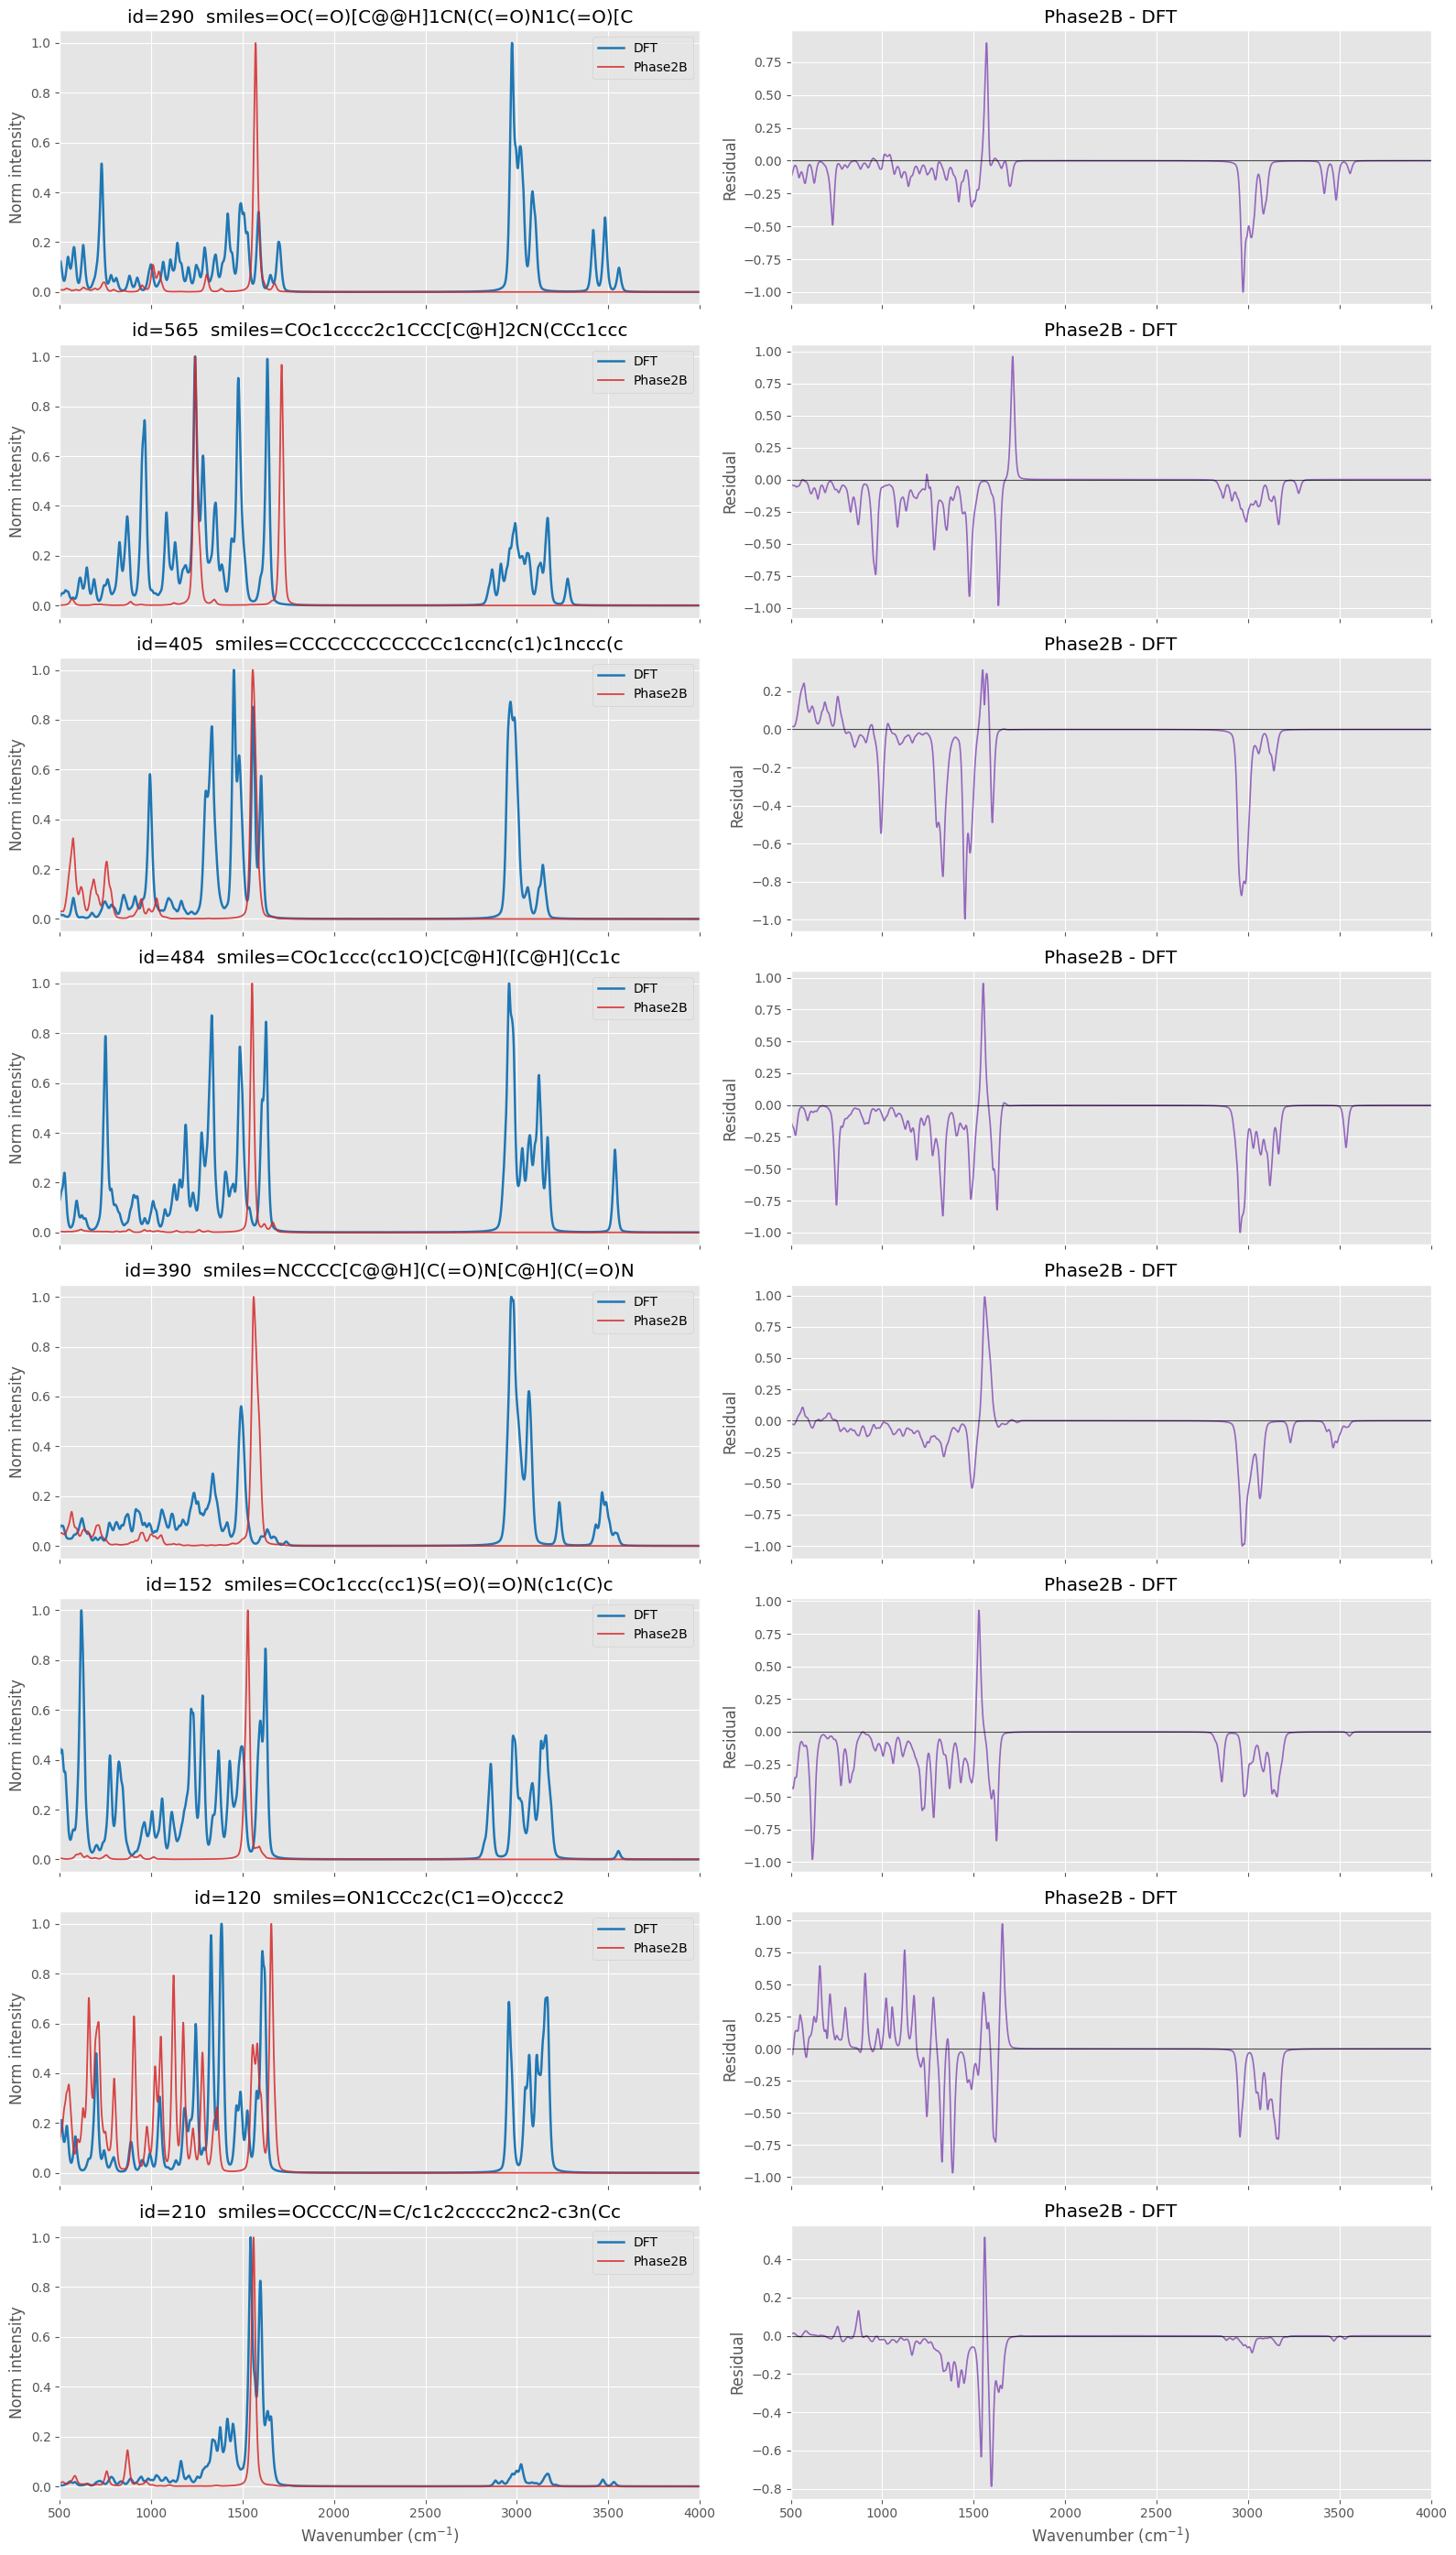

Phase2B random-case count: 8
Fréchet median (95% bootstrap CI): 0.989285 [0.972249, 0.999992]
RMSE median (95% bootstrap CI): 0.172798 [0.142359, 0.204837]
Corr median (95% bootstrap CI): 0.128839 [-0.004435, 0.304184]


In [21]:
# Phase 2B random-sample comparison: predicted vs DFT + Fréchet bootstrap CI
if 'PHASE2B_CFG' not in globals():
    raise RuntimeError('Run the Phase 2B config cell first so PHASE2B_CFG is available.')

x_grid = x_axis_r2a if 'x_axis_r2a' in globals() else np.linspace(500.0, 4000.0, 3501)

R2B_RANDOM_SEED = 123
R2B_POOL_LIMIT = 600
R2B_TARGET_CASES = 8
R2B_SHOW_PLOTS = 15
R2B_BOOT_ITERS = 1000
R2B_BOOT_SEED = 1234
R2B_FRECHET_DOWNSAMPLE = 0


def discrete_frechet_distance(curve_a, curve_b):
    """Discrete Fréchet distance for 2D curves (iterative DP)."""
    P = np.asarray(curve_a, dtype=np.float64)
    Q = np.asarray(curve_b, dtype=np.float64)
    n, m = P.shape[0], Q.shape[0]
    if n == 0 or m == 0:
        return np.nan

    ca = np.empty((n, m), dtype=np.float64)
    ca.fill(np.nan)

    def d(i, j):
        return np.linalg.norm(P[i] - Q[j])

    ca[0, 0] = d(0, 0)
    for i in range(1, n):
        ca[i, 0] = max(ca[i - 1, 0], d(i, 0))
    for j in range(1, m):
        ca[0, j] = max(ca[0, j - 1], d(0, j))

    for i in range(1, n):
        for j in range(1, m):
            ca[i, j] = max(min(ca[i - 1, j], ca[i - 1, j - 1], ca[i, j - 1]), d(i, j))

    return float(ca[n - 1, m - 1])


def curve_points_for_frechet(x, y, downsample=5):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    step = max(1, int(downsample))
    idx = np.arange(0, x.shape[0], step, dtype=np.int64)
    if idx[-1] != x.shape[0] - 1:
        idx = np.append(idx, x.shape[0] - 1)
    return np.stack([x[idx], y[idx]], axis=1)


def bootstrap_ci(values, stat_fn=np.median, n_boot=1000, seed=0, alpha=0.05):
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {'point': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'n': 0}

    rng = np.random.default_rng(seed)
    boot = np.empty(int(n_boot), dtype=np.float64)
    n = arr.size
    for i in range(int(n_boot)):
        sample = rng.choice(arr, size=n, replace=True)
        boot[i] = float(stat_fn(sample))

    q_lo, q_hi = np.quantile(boot, [alpha / 2.0, 1.0 - alpha / 2.0])
    return {
        'point': float(stat_fn(arr)),
        'ci_low': float(q_lo),
        'ci_high': float(q_hi),
        'n': int(n),
    }


def _random_payload_rows(db_path, limit=600, seed=123):
    con = sqlite3.connect(db_path)
    try:
        cur = con.cursor()
        cur.execute(
            'SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
            (int(limit),),
        )
        rows = cur.fetchall()
    finally:
        con.close()

    rng = np.random.default_rng(seed)
    if len(rows) > 1:
        rng.shuffle(rows)
    return rows


rows = _random_payload_rows(db_path, limit=R2B_POOL_LIMIT, seed=R2B_RANDOM_SEED)
records = []
plot_payloads = []

for rid, smiles, blob in rows:
    if len(records) >= int(R2B_TARGET_CASES):
        break

    try:
        payload = decode_blob_payload(blob)
        freq_gt_local = np.asarray(payload.get('freq', []), dtype=np.float64)
        raman_gt_local = np.asarray(payload.get('Raman Activ', []), dtype=np.float64)
        if freq_gt_local.size == 0 or raman_gt_local.size == 0:
            continue

        if _edge_count_for_payload(payload, device=device, rc=5.0) == 0:
            continue

        z_local = torch.tensor(np.asarray(payload['atoms'], dtype=np.int64), dtype=torch.long, device=device)
        pos_local = torch.tensor(np.asarray(payload['coord'], dtype=np.float32), dtype=torch.float32, device=device)
        batch_local = torch.zeros(z_local.shape[0], dtype=torch.long, device=device)

        freq_pred_local, raman_pred_local, diag_local = predict_raman_lines_phase2b(
            z=z_local,
            pos=pos_local,
            batch=batch_local,
            model_hi=model_hi,
            model_hij=model_hij,
            model_polar=model_polar,
            rc=5.0,
            step_sizes=PHASE2B_CFG['step_sizes'],
            richardson_order=PHASE2B_CFG['richardson_order'],
            richardson_blend=PHASE2B_CFG['richardson_blend'],
            mode_chunk=PHASE2B_CFG['mode_chunk'],
            show_progress=False,
        )

        y_true = lines_to_norm_spectrum_phase2b(
            freq_gt_local,
            raman_gt_local,
            x_grid,
            scale=1.0,
            beta=0.0,
            high_scale=1.0,
            sigma=PHASE2B_CFG['sigma'],
            gamma=PHASE2B_CFG['gamma'],
            eta=PHASE2B_CFG['eta'],
            slope=PHASE2B_CFG['slope'],
            temp=PHASE2B_CFG['temp'],
            init_wl=PHASE2B_CFG['init_wl'],
        )

        y_pred = lines_to_norm_spectrum_phase2b(
            freq_pred_local,
            raman_pred_local,
            x_grid,
            scale=PHASE2B_CFG['scale'],
            beta=PHASE2B_CFG['beta'],
            high_scale=PHASE2B_CFG['high_scale'],
            sigma=PHASE2B_CFG['sigma'],
            gamma=PHASE2B_CFG['gamma'],
            eta=PHASE2B_CFG['eta'],
            slope=PHASE2B_CFG['slope'],
            temp=PHASE2B_CFG['temp'],
            init_wl=PHASE2B_CFG['init_wl'],
        )

        m = spectrum_metrics(y_pred, y_true)
        c_true = curve_points_for_frechet(x_grid, y_true, downsample=R2B_FRECHET_DOWNSAMPLE)
        c_pred = curve_points_for_frechet(x_grid, y_pred, downsample=R2B_FRECHET_DOWNSAMPLE)
        frechet = discrete_frechet_distance(c_pred, c_true)

        rec = {
            'id': int(rid),
            'smiles': smiles,
            'n_atoms': int(z_local.shape[0]),
            'n_modes_pred': int(diag_local['n_modes_pred']),
            'rmse': float(m['rmse']),
            'corr': float(m['corr']) if np.isfinite(m['corr']) else np.nan,
            'peak_rmse': float(m['peak_rmse']) if np.isfinite(m['peak_rmse']) else np.nan,
            'frechet': float(frechet),
        }
        records.append(rec)

        plot_payloads.append({
            'id': int(rid),
            'smiles': smiles,
            'y_true': y_true,
            'y_pred': y_pred,
        })
    except Exception:
        continue

if len(records) == 0:
    raise RuntimeError('No valid random cases were evaluated. Increase R2B_POOL_LIMIT or inspect data/model load.')

df_r2b_random = pd.DataFrame(records).sort_values('frechet', ascending=True).reset_index(drop=True)
display(df_r2b_random)

# Plot a few random overlays + residuals.
show_n = min(int(R2B_SHOW_PLOTS), len(plot_payloads))
if show_n > 0:
    fig, axes = plt.subplots(show_n, 2, figsize=(16, 3.5 * show_n), sharex=True)
    if show_n == 1:
        axes = np.array([axes])

    for i in range(show_n):
        p = plot_payloads[i]
        y_true = p['y_true']
        y_pred = p['y_pred']
        resid = y_pred - y_true

        axes[i, 0].plot(x_grid, y_true, lw=1.8, color='tab:blue', label='DFT')
        axes[i, 0].plot(x_grid, y_pred, lw=1.3, color='tab:red', alpha=0.85, label='Phase2B')
        axes[i, 0].set_xlim(500, 4000)
        axes[i, 0].set_ylabel('Norm intensity')
        axes[i, 0].set_title(f"id={p['id']}  smiles={str(p['smiles'])[:30]}")
        axes[i, 0].legend(loc='upper right')

        axes[i, 1].plot(x_grid, resid, lw=1.2, color='tab:purple')
        axes[i, 1].axhline(0.0, color='k', lw=0.8, alpha=0.7)
        axes[i, 1].set_xlim(500, 4000)
        axes[i, 1].set_ylabel('Residual')
        axes[i, 1].set_title('Phase2B - DFT')

    axes[-1, 0].set_xlabel('Wavenumber (cm$^{-1}$)')
    axes[-1, 1].set_xlabel('Wavenumber (cm$^{-1}$)')
    plt.tight_layout()
    plt.show()

# Bootstrap CIs for curve-difference metrics.
frechet_ci = bootstrap_ci(df_r2b_random['frechet'].values, stat_fn=np.median, n_boot=R2B_BOOT_ITERS, seed=R2B_BOOT_SEED)
rmse_ci = bootstrap_ci(df_r2b_random['rmse'].values, stat_fn=np.median, n_boot=R2B_BOOT_ITERS, seed=R2B_BOOT_SEED + 1)
corr_ci = bootstrap_ci(df_r2b_random['corr'].values, stat_fn=np.median, n_boot=R2B_BOOT_ITERS, seed=R2B_BOOT_SEED + 2)

print(f"Phase2B random-case count: {len(df_r2b_random)}")
print(
    'Fréchet median (95% bootstrap CI): '
    f"{frechet_ci['point']:.6f} [{frechet_ci['ci_low']:.6f}, {frechet_ci['ci_high']:.6f}]"
)
print(
    'RMSE median (95% bootstrap CI): '
    f"{rmse_ci['point']:.6f} [{rmse_ci['ci_low']:.6f}, {rmse_ci['ci_high']:.6f}]"
)
print(
    'Corr median (95% bootstrap CI): '
    f"{corr_ci['point']:.6f} [{corr_ci['ci_low']:.6f}, {corr_ci['ci_high']:.6f}]"
)

## Phase 3

### Phase 3A: Learned Spectral Calibrator

This phase adds a lightweight calibrator on top of the least-offensive base phase output.

Components implemented:
- monotone frequency warp (piecewise-linear monotone map via cumulative softplus increments),
- learned pseudo-Voigt broadening,
- metadata-conditioned amplitude calibration,
- training objective combining Wasserstein-style CDF loss (EMD surrogate), cosine loss, and MSE on area-normalized spectra.

Metadata used:
- molecular weight,
- atom counts (C/H/N/O/halogens),
- approximate ring count from SMILES,
- model-derived proxies (peak position, centroid, CH-stretch-region energy proxy).



In [ ]:
# Phase 3A.1 - Build calibration dataset from least-offensive phase output (scaled)
import os
import re
import json
import pickle
import hashlib
import time
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

if 'model_hi' not in globals() or 'model_hij' not in globals() or 'model_polar' not in globals():
    raise RuntimeError('Run model setup/inference cells before Phase 3.')

CAL_GRID_POINTS = 512
x_grid_cal = np.linspace(500.0, 4000.0, CAL_GRID_POINTS, dtype=np.float64)

# Large-run knobs
CAL_SEED = 2026
CAL_POOL_LIMIT = 9000           # DB rows to scan
CAL_MAX_CASES = 5200            # full target size
CAL_FULL_TARGET_CASES = 5200    # used for ETA reporting during benchmark
CAL_RUN_BENCHMARK_ONLY = False   # run only CAL_BENCHMARK_CASES now
CAL_BENCHMARK_CASES = 100       # timing probe
CAL_PHASE_SELECT_CASES = 0      # unused when base phase is overridden
CAL_RC = 5.0
CAL_DELTA = 0.005
CAL_GT_SIGMA = float(best_sigma) if 'best_sigma' in globals() else 10.0
CAL_FREQ_SCALE = float(best_scale) if 'best_scale' in globals() else 0.96
CAL_INCLUDE_PHASE2B = False     # expensive; keep False for large runs
CAL_BASE_PHASE_OVERRIDE = 'round2a'  # fixed fast path: skip pass-1 and use Round2A only

# --- THE FIX ---
CAL_ACT_POWER = 0.45  # Dynamic range compression (0.5 = sqrt). Lowers the giants, boosts the hidden modes.

# Parallel + cache knobs
CAL_NUM_WORKERS = min(16, (os.cpu_count() or 16))
CAL_CACHE_VERSION = 1
CAL_CACHE_DIR = Path('artifacts/calibration_cache')
CAL_CACHE_SAVE_EVERY = 250

rng_cal = np.random.default_rng(CAL_SEED)

ATOMIC_WEIGHTS = {
    1: 1.008, 6: 12.011, 7: 14.007, 8: 15.999,
    9: 18.998, 15: 30.974, 16: 32.06, 17: 35.45,
    35: 79.904, 53: 126.90,
}
HALOGENS = {9, 17, 35, 53}


def _area_normalize_np(y, eps=1e-12):
    y = np.asarray(y, dtype=np.float64)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    y = np.clip(y, 0.0, None)
    s = float(y.sum())
    return y / (s + eps)


def _cosine_np(a, b, eps=1e-12):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    den = (np.linalg.norm(a) * np.linalg.norm(b)) + eps
    return float(np.dot(a, b) / den)


def _emd_cdf_np(a, b):
    a = _area_normalize_np(a)
    b = _area_normalize_np(b)
    return float(np.mean(np.abs(np.cumsum(a) - np.cumsum(b))))


def _spec_metrics_area(y_pred, y_true):
    y_pred = _area_normalize_np(y_pred)
    y_true = _area_normalize_np(y_true)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    cos = _cosine_np(y_pred, y_true)
    emd = _emd_cdf_np(y_pred, y_true)
    return {'rmse': rmse, 'cosine': cos, 'emd': emd}


def _approx_ring_count_from_smiles(smiles):
    if not isinstance(smiles, str) or len(smiles) == 0:
        return 0.0
    digit_count = len(re.findall(r'[0-9]', smiles))
    return float(digit_count // 2)


def _compute_metadata(smiles, atoms_z, base_spec, x_grid):
    z = np.asarray(atoms_z, dtype=np.int64)
    n_atoms = float(z.size)
    mw = float(sum(ATOMIC_WEIGHTS.get(int(zi), 12.0) for zi in z))

    c_count = float(np.sum(z == 6))
    h_count = float(np.sum(z == 1))
    n_count = float(np.sum(z == 7))
    o_count = float(np.sum(z == 8))
    hal_count = float(np.sum([zi in HALOGENS for zi in z]))
    ring_count = _approx_ring_count_from_smiles(smiles)

    y = _area_normalize_np(base_spec)
    x = np.asarray(x_grid, dtype=np.float64)
    peak_cm = float(x[np.argmax(y)])
    centroid = float(np.sum(x * y) / (np.sum(y) + 1e-12))
    width = float(np.sqrt(np.sum(y * (x - centroid) ** 2) / (np.sum(y) + 1e-12)))

    ch_mask = (x >= 2800.0) & (x <= 3100.0)
    ch_proxy = float(np.sum(y[ch_mask]) / (np.sum(y) + 1e-12))

    return np.array([
        n_atoms, mw,
        c_count, h_count, n_count, o_count, hal_count, ring_count,
        peak_cm, centroid, width, ch_proxy,
    ], dtype=np.float32)


def _phase_predict_lines(phase, z_t, pos_t, batch_t):
    if phase == 'phase1':
        return predict_raman_from_heads(
            z=z_t, pos=pos_t, batch=batch_t,
            model_hi=model_hi, model_hij=model_hij, model_polar=model_polar,
            delta=CAL_DELTA, rc=CAL_RC, scale=None,
        )
    if phase == 'round2a':
        return predict_raman_lines_round2a(
            z=z_t, pos=pos_t, batch=batch_t,
            model_hi=model_hi, model_hij=model_hij, model_polar=model_polar,
            rc=CAL_RC, scale=None,
        )
    if phase == 'phase2b':
        if 'predict_raman_lines_phase2b' not in globals() or 'PHASE2B_CFG' not in globals():
            raise RuntimeError('Phase2B function/config not available in globals.')
        f, a, _ = predict_raman_lines_phase2b(
            z=z_t, pos=pos_t, batch=batch_t,
            model_hi=model_hi, model_hij=model_hij, model_polar=model_polar,
            rc=CAL_RC,
            step_sizes=PHASE2B_CFG['step_sizes'],
            richardson_order=PHASE2B_CFG['richardson_order'],
            richardson_blend=PHASE2B_CFG['richardson_blend'],
            mode_chunk=PHASE2B_CFG['mode_chunk'],
            show_progress=False,
        )
        return f, a
    raise ValueError(f'Unknown phase={phase}')


def _phase_lines_to_spec(phase, freq_pred, act_pred):
    # Fix 2: Compress the dynamic range to rescue hidden modes before rendering
    act_compressed = np.power(np.clip(act_pred, 0.0, None), CAL_ACT_POWER)

    if phase == 'phase2b':
        if 'predict_raman_lines_phase2b' not in globals() or 'PHASE2B_CFG' not in globals():
            raise RuntimeError('Phase2B function/config not available in globals.')
        y = lines_to_norm_spectrum_phase2b(
            freq_pred, act_compressed, x_grid_cal,
            scale=PHASE2B_CFG['scale'],
            beta=PHASE2B_CFG['beta'],
            high_scale=PHASE2B_CFG['high_scale'],
            sigma=PHASE2B_CFG['sigma'],
            gamma=PHASE2B_CFG['gamma'],
            eta=PHASE2B_CFG['eta'],
            slope=PHASE2B_CFG['slope'],
            temp=PHASE2B_CFG['temp'],
            init_wl=PHASE2B_CFG['init_wl'],
        )
    else:
        y = lines_to_norm_spectrum(
            np.asarray(freq_pred) * CAL_FREQ_SCALE,
            act_compressed,
            x_grid_cal,
            sigma=CAL_GT_SIGMA,
        )
    return _area_normalize_np(y)


def _gt_to_spec(freq_gt, act_gt):
    # Fix 2: Compress the ground truth so the calibrator target matches our compressed inputs
    act_compressed = np.power(np.clip(act_gt, 0.0, None), CAL_ACT_POWER)
    y = lines_to_norm_spectrum(freq_gt, act_compressed, x_grid_cal, sigma=CAL_GT_SIGMA)
    return _area_normalize_np(y)


def _blob_signature(blob):
    if blob is None:
        return ''
    if isinstance(blob, memoryview):
        blob = blob.tobytes()
    if not isinstance(blob, (bytes, bytearray)):
        blob = bytes(blob)
    return hashlib.blake2b(blob, digest_size=12).hexdigest()


def _config_hash_for_cache():
    cfg = {
        'v': CAL_CACHE_VERSION,
        'seed': int(CAL_SEED),
        'rc': float(CAL_RC),
        'delta': float(CAL_DELTA),
        'gt_sigma': float(CAL_GT_SIGMA),
        'freq_scale': float(CAL_FREQ_SCALE),
        'act_power': float(CAL_ACT_POWER),
        'include_phase2b': bool(CAL_INCLUDE_PHASE2B),
        'x_grid_hash': hashlib.blake2b(np.asarray(x_grid_cal, dtype=np.float32).tobytes(), digest_size=8).hexdigest(),
        'db_path': str(db_path),
    }
    return hashlib.blake2b(json.dumps(cfg, sort_keys=True).encode('utf-8'), digest_size=12).hexdigest()


def _load_cal_cache(path):
    if not path.exists():
        return {'version': CAL_CACHE_VERSION, 'rows': {}}
    try:
        with path.open('rb') as f:
            obj = pickle.load(f)
        if not isinstance(obj, dict):
            return {'version': CAL_CACHE_VERSION, 'rows': {}}
        rows = obj.get('rows', {})
        if not isinstance(rows, dict):
            rows = {}
        return {'version': CAL_CACHE_VERSION, 'rows': rows}
    except Exception as exc:
        print(f'Cache load failed at {path}: {exc}. Starting fresh.')
        return {'version': CAL_CACHE_VERSION, 'rows': {}}


def _save_cal_cache(path, obj):
    tmp = path.with_suffix(path.suffix + '.tmp')
    with tmp.open('wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    tmp.replace(path)


def _cache_entry_valid(row, entry, required_phases):
    if not isinstance(entry, dict):
        return False
    if entry.get('blob_sig') != _blob_signature(row[2]):
        return False
    if 'atoms' not in entry or 'y_true' not in entry:
        return False
    phase_specs = entry.get('phase_specs', {})
    if not isinstance(phase_specs, dict):
        return False
    return all(ph in phase_specs for ph in required_phases)


def _cache_entry_to_result(row, entry, required_phases):
    rid, smiles, _ = row
    phase_specs = {
        ph: np.asarray(entry['phase_specs'][ph], dtype=np.float32)
        for ph in required_phases
    }
    return {
        'id': int(rid),
        'smiles': smiles,
        'blob_sig': entry['blob_sig'],
        'atoms': np.asarray(entry['atoms'], dtype=np.int64),
        'y_true': np.asarray(entry['y_true'], dtype=np.float32),
        'phase_specs': phase_specs,
    }


def _upsert_cache_entry(cache_rows, row_result):
    rid = int(row_result['id'])
    entry = cache_rows.get(rid)
    if not isinstance(entry, dict) or entry.get('blob_sig') != row_result['blob_sig']:
        entry = {'blob_sig': row_result['blob_sig'], 'phase_specs': {}}

    entry['smiles'] = row_result['smiles']
    entry['atoms'] = np.asarray(row_result['atoms'], dtype=np.int16)
    entry['y_true'] = np.asarray(row_result['y_true'], dtype=np.float32)

    phase_specs = entry.get('phase_specs', {})
    for ph, y in row_result['phase_specs'].items():
        phase_specs[str(ph)] = np.asarray(y, dtype=np.float32)
    entry['phase_specs'] = phase_specs

    cache_rows[rid] = entry


def _compute_row_bundle(row, required_phases):
    rid, smiles, blob = row
    try:
        payload = decode_blob_payload(blob)
        freq_gt = np.asarray(payload.get('freq', []), dtype=np.float64)
        act_gt = np.asarray(payload.get('Raman Activ', []), dtype=np.float64)
        if freq_gt.size == 0 or act_gt.size == 0:
            return None

        atoms = np.asarray(payload['atoms'], dtype=np.int64)
        coords = np.asarray(payload['coord'], dtype=np.float32)
        z_t = torch.tensor(atoms, dtype=torch.long, device=device)
        pos_t = torch.tensor(coords, dtype=torch.float32, device=device)
        batch_t = torch.zeros(z_t.shape[0], dtype=torch.long, device=device)

        y_true_local = _gt_to_spec(freq_gt, act_gt).astype(np.float32)
        phase_specs = {}
        for ph in required_phases:
            f_pred, a_pred = _phase_predict_lines(ph, z_t, pos_t, batch_t)
            phase_specs[ph] = _phase_lines_to_spec(ph, f_pred, a_pred).astype(np.float32)

        return {
            'id': int(rid),
            'smiles': smiles,
            'blob_sig': _blob_signature(blob),
            'atoms': atoms.astype(np.int16),
            'y_true': y_true_local,
            'phase_specs': phase_specs,
        }
    except Exception:
        return None


def _collect_rows_with_cache(rows, required_phases, max_cases, progress_every, label, cache_rows, cache_obj, cache_path, workers):
    required_phases = tuple(required_phases)
    results = []
    cache_hits = 0
    computed = 0
    cache_updates = 0

    if workers <= 1:
        for row in rows:
            if len(results) >= max_cases:
                break

            rid = int(row[0])
            entry = cache_rows.get(rid)
            if _cache_entry_valid(row, entry, required_phases):
                results.append(_cache_entry_to_result(row, entry, required_phases))
                cache_hits += 1
            else:
                out = _compute_row_bundle(row, required_phases)
                if out is None:
                    continue
                _upsert_cache_entry(cache_rows, out)
                cache_updates += 1
                computed += 1
                results.append(out)

                if cache_updates % max(1, int(CAL_CACHE_SAVE_EVERY)) == 0:
                    _save_cal_cache(cache_path, cache_obj)

            if progress_every > 0 and (len(results) % progress_every == 0):
                print(f'{label}: {len(results)}/{max_cases} (cache_hits={cache_hits}, computed={computed})')

        return results, cache_hits, computed, cache_updates

    batch_size = max(int(workers) * 4, int(workers))
    n_rows = len(rows)
    idx = 0

    with ThreadPoolExecutor(max_workers=int(workers)) as ex:
        while idx < n_rows and len(results) < max_cases:
            batch_rows = []
            while idx < n_rows and len(batch_rows) < batch_size and len(results) < max_cases:
                row = rows[idx]
                idx += 1

                rid = int(row[0])
                entry = cache_rows.get(rid)
                if _cache_entry_valid(row, entry, required_phases):
                    results.append(_cache_entry_to_result(row, entry, required_phases))
                    cache_hits += 1
                    if progress_every > 0 and (len(results) % progress_every == 0):
                        print(f'{label}: {len(results)}/{max_cases} (cache_hits={cache_hits}, computed={computed})')
                else:
                    batch_rows.append(row)

            if len(results) >= max_cases:
                break
            if not batch_rows:
                continue

            phase_args = [required_phases] * len(batch_rows)
            for out in ex.map(_compute_row_bundle, batch_rows, phase_args):
                if out is None:
                    continue

                _upsert_cache_entry(cache_rows, out)
                cache_updates += 1
                computed += 1
                results.append(out)

                if cache_updates % max(1, int(CAL_CACHE_SAVE_EVERY)) == 0:
                    _save_cal_cache(cache_path, cache_obj)

                if progress_every > 0 and (len(results) % progress_every == 0):
                    print(f'{label}: {len(results)}/{max_cases} (cache_hits={cache_hits}, computed={computed})')

                if len(results) >= max_cases:
                    break

    return results, cache_hits, computed, cache_updates


_device_type = str(getattr(device, 'type', device)).lower() if 'device' in globals() else 'cpu'
if _device_type == 'cuda' and CAL_NUM_WORKERS > 1:
    print(f'Using CAL_NUM_WORKERS=1 on CUDA to avoid GPU contention in threaded inference.')
    CAL_NUM_WORKERS = 1
elif _device_type == 'mps':
    print(f'Using CAL_NUM_WORKERS={CAL_NUM_WORKERS} on MPS for threaded row processing.')

# Load rows once and shuffle
con = sqlite3.connect(db_path)
try:
    cur = con.cursor()
    cur.execute(
        'SELECT id, SMILES, blob_data FROM molecule WHERE blob_data IS NOT NULL ORDER BY id LIMIT ?',
        (int(CAL_POOL_LIMIT),),
    )
    cal_rows = cur.fetchall()
finally:
    con.close()

if len(cal_rows) > 1:
    rng_cal.shuffle(cal_rows)

CAL_EFFECTIVE_MAX_CASES = int(CAL_BENCHMARK_CASES if CAL_RUN_BENCHMARK_ONLY else CAL_MAX_CASES)
print(f'Row scan limit={CAL_POOL_LIMIT} | target={CAL_EFFECTIVE_MAX_CASES} | benchmark_only={CAL_RUN_BENCHMARK_ONLY}')

CAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CAL_CACHE_PATH = CAL_CACHE_DIR / f'phase3a1_{_config_hash_for_cache()}.pkl'
cal_cache = _load_cal_cache(CAL_CACHE_PATH)
cal_cache_rows = cal_cache['rows']
print(f'Calibration cache: {CAL_CACHE_PATH} | workers={CAL_NUM_WORKERS} | cached_rows={len(cal_cache_rows)}')

# -------- Pass 1: choose least-offensive base phase on small subset --------
candidate_phases = ['phase1', 'round2a']
if CAL_INCLUDE_PHASE2B:
    candidate_phases.append('phase2b')

if CAL_BASE_PHASE_OVERRIDE is None:
    phase_results, cache_hits_p1, computed_p1, cache_updates_p1 = _collect_rows_with_cache(
        rows=cal_rows,
        required_phases=candidate_phases,
        max_cases=int(CAL_PHASE_SELECT_CASES),
        progress_every=25,
        label='Phase-selection',
        cache_rows=cal_cache_rows,
        cache_obj=cal_cache,
        cache_path=CAL_CACHE_PATH,
        workers=CAL_NUM_WORKERS,
    )

    if len(phase_results) == 0:
        raise RuntimeError('No candidate phase metrics available for base-phase selection.')

    phase_metric_acc = defaultdict(list)
    eligible_cache = []
    for row_out in phase_results:
        y_true_local = row_out['y_true']
        atoms = row_out['atoms']

        any_ok = False
        for ph in candidate_phases:
            y_pred = row_out['phase_specs'].get(ph)
            if y_pred is None:
                continue
            m = _spec_metrics_area(y_pred, y_true_local)
            phase_metric_acc[ph].append(m)
            any_ok = True

        if any_ok and len(eligible_cache) < 32:
            eligible_cache.append((int(row_out['id']), row_out['smiles'], atoms, y_true_local))

    phase_rows = []
    for ph in candidate_phases:
        rows = phase_metric_acc.get(ph, [])
        if len(rows) == 0:
            continue
        rmse_med = float(np.median([r['rmse'] for r in rows]))
        cos_med = float(np.median([r['cosine'] for r in rows]))
        emd_med = float(np.median([r['emd'] for r in rows]))
        score_med = float(np.median([r['emd'] + 0.5 * r['rmse'] + 0.25 * (1.0 - r['cosine']) for r in rows]))
        phase_rows.append({
            'phase': ph,
            'n_cases': len(rows),
            'rmse_median': rmse_med,
            'cosine_median': cos_med,
            'emd_median': emd_med,
            'score_median': score_med,
        })

    df_phase_rank = pd.DataFrame(phase_rows).sort_values(['score_median', 'emd_median', 'rmse_median'], ascending=True).reset_index(drop=True)
    if len(df_phase_rank) == 0:
        raise RuntimeError('No candidate phase metrics available for base-phase selection.')

    display(df_phase_rank)
    CAL_BASE_PHASE = str(df_phase_rank.iloc[0]['phase'])
    print('Selected least-offensive base phase:', CAL_BASE_PHASE)
    print(f'Pass 1 summary: cached={cache_hits_p1}, computed={computed_p1}, used={len(phase_results)}')
else:
    CAL_BASE_PHASE = str(CAL_BASE_PHASE_OVERRIDE)
    if CAL_BASE_PHASE not in {'phase1', 'round2a', 'phase2b'}:
        raise ValueError(f'Unsupported CAL_BASE_PHASE_OVERRIDE={CAL_BASE_PHASE}')
    if CAL_BASE_PHASE == 'phase2b' and not CAL_INCLUDE_PHASE2B:
        raise ValueError('CAL_BASE_PHASE_OVERRIDE=phase2b requires CAL_INCLUDE_PHASE2B=True')
    cache_hits_p1 = 0
    computed_p1 = 0
    cache_updates_p1 = 0
    print(f'Using CAL_BASE_PHASE_OVERRIDE={CAL_BASE_PHASE}; skipping pass-1 phase selection.')

# -------- Pass 2: build large dataset with selected base phase only --------
build_t0 = time.perf_counter()
build_results, cache_hits_p2, computed_p2, cache_updates_p2 = _collect_rows_with_cache(
    rows=cal_rows,
    required_phases=[CAL_BASE_PHASE],
    max_cases=int(CAL_EFFECTIVE_MAX_CASES),
    progress_every=250,
    label='Dataset build',
    cache_rows=cal_cache_rows,
    cache_obj=cal_cache,
    cache_path=CAL_CACHE_PATH,
    workers=CAL_NUM_WORKERS,
)

built = len(build_results)
_min_required = min(100, int(CAL_EFFECTIVE_MAX_CASES))
if built < _min_required:
    raise RuntimeError(f'Only built {built} cases (<{_min_required}); increase CAL_POOL_LIMIT or inspect data quality.')

ids = []
smiles_list = []
x_base = []
y_true = []
meta_raw = []
base_scores = []

for row_out in build_results:
    yb = np.asarray(row_out['phase_specs'][CAL_BASE_PHASE], dtype=np.float32)
    yt = np.asarray(row_out['y_true'], dtype=np.float32)
    atoms = np.asarray(row_out['atoms'], dtype=np.int64)
    smiles = row_out['smiles']

    m = _spec_metrics_area(yb, yt)
    score = m['emd'] + 0.5 * m['rmse'] + 0.25 * (1.0 - m['cosine'])
    md = _compute_metadata(smiles, atoms, yb, x_grid_cal)

    ids.append(int(row_out['id']))
    smiles_list.append(smiles)
    x_base.append(yb)
    y_true.append(yt)
    meta_raw.append(md.astype(np.float32))
    base_scores.append(float(score))

x_base = np.stack(x_base, axis=0)
y_true = np.stack(y_true, axis=0)
meta_raw = np.stack(meta_raw, axis=0)
ids = np.asarray(ids, dtype=np.int64)
base_scores = np.asarray(base_scores, dtype=np.float32)

N = x_base.shape[0]
perm = rng_cal.permutation(N)

n_train = int(round(0.70 * N))
n_val = int(round(0.15 * N))
n_test = N - n_train - n_val
if n_test < 1:
    n_test = 1
    n_train = max(1, n_train - 1)

train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

print(f'Calibration dataset size: N={N} (train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)})')
build_dt = time.perf_counter() - build_t0
build_min = build_dt / 60.0
throughput = built / max(build_dt, 1e-9)
remaining = max(0, int(CAL_FULL_TARGET_CASES) - built)
eta_hours = remaining / max(throughput, 1e-9) / 3600.0
print(f'Pass 2 summary: cached={cache_hits_p2}, computed={computed_p2}, used={built}')
print(f'Build timing: {build_min:.2f} min for {built} rows | throughput={throughput:.4f} mol/s')
print(f'Projected ETA to {CAL_FULL_TARGET_CASES}: ~{eta_hours:.2f} hours (assuming steady throughput)')

if (cache_updates_p1 + cache_updates_p2) > 0:
    _save_cal_cache(CAL_CACHE_PATH, cal_cache)
    print(f'Cache updated: {CAL_CACHE_PATH} (new_or_refreshed_rows={cache_updates_p1 + cache_updates_p2})')
else:
    print('Cache reused without updates.')

phase3_data = {
    'x_base': x_base,
    'y_true': y_true,
    'meta_raw': meta_raw,
    'ids': ids,
    'smiles': smiles_list,
    'base_scores': base_scores,
    'splits': {
        'train': train_idx,
        'val': val_idx,
        'test': test_idx,
    },
    'base_phase': CAL_BASE_PHASE,
    'x_grid': x_grid_cal,
}

if CAL_RUN_BENCHMARK_ONLY:
    print('Benchmark mode finished. Set CAL_RUN_BENCHMARK_ONLY=False for full dataset build.')



Using CAL_NUM_WORKERS=16 on MPS for threaded row processing.
Row scan limit=9000 | target=5200 | benchmark_only=False
Calibration cache: artifacts/calibration_cache/phase3a1_bd4647f32dcf5ca280c75499.pkl | workers=16 | cached_rows=0
Using CAL_BASE_PHASE_OVERRIDE=round2a; skipping pass-1 phase selection.
Dataset build: 250/5200 (cache_hits=0, computed=250)
Dataset build: 500/5200 (cache_hits=0, computed=500)
Dataset build: 750/5200 (cache_hits=0, computed=750)
Dataset build: 1000/5200 (cache_hits=0, computed=1000)
Dataset build: 1250/5200 (cache_hits=0, computed=1250)
Dataset build: 1500/5200 (cache_hits=0, computed=1500)
Dataset build: 1750/5200 (cache_hits=0, computed=1750)
Dataset build: 2000/5200 (cache_hits=0, computed=2000)


Calibrator device: mps
Epoch 001 | train=0.817017 val=0.554936 val_emd=0.074460 val_cos=0.404899
Epoch 005 | train=0.373350 val=0.337619 val_emd=0.043983 val_cos=0.249023
Epoch 010 | train=0.309734 val=0.297022 val_emd=0.028463 val_cos=0.239614
Epoch 015 | train=0.246815 val=0.276239 val_emd=0.026201 val_cos=0.223379
Epoch 020 | train=0.267109 val=0.270420 val_emd=0.025419 val_cos=0.219267
Epoch 025 | train=0.276768 val=0.258252 val_emd=0.020992 val_cos=0.215969
Epoch 030 | train=0.258415 val=0.254731 val_emd=0.019635 val_cos=0.215240
Epoch 035 | train=0.243253 val=0.252435 val_emd=0.019025 val_cos=0.214173
Epoch 040 | train=0.254952 val=0.254261 val_emd=0.019472 val_cos=0.215092
Epoch 045 | train=0.264584 val=0.251897 val_emd=0.019385 val_cos=0.212918
Epoch 050 | train=0.246057 val=0.249302 val_emd=0.018367 val_cos=0.212343
Epoch 055 | train=0.233834 val=0.253435 val_emd=0.019621 val_cos=0.213966
Epoch 060 | train=0.252924 val=0.250679 val_emd=0.018886 val_cos=0.212733
Epoch 065 | tra

,id,rmse_base,rmse_cal,cos_base,cos_cal,emd_base,emd_cal,frechet_base,frechet_cal,delta_rmse_base_minus_cal,delta_emd_base_minus_cal,delta_cos_cal_minus_base,delta_frechet_base_minus_cal
0,8588,0.002569,0.001229,0.474336,0.790224,0.037100,0.022173,0.044933,0.008025,0.001340,0.014927,0.315888,0.036908
1,2178,0.002400,0.001006,0.479603,0.837933,0.097714,0.008797,0.017798,0.002451,0.001394,0.088917,0.358330,0.015347
2,6061,0.002753,0.001298,0.365202,0.756536,0.132019,0.013158,0.019118,0.007701,0.001455,0.118860,0.391333,0.011417
3,3027,0.002369,0.000928,0.464733,0.854731,0.146082,0.016039,0.011654,0.004338,0.001441,0.130043,0.389998,0.007316
4,7396,0.004591,0.001210,0.297130,0.789151,0.082210,0.008928,0.010449,0.003399,0.003380,0.073281,0.492021,0.007049
5,7035,0.001970,0.001245,0.591092,0.779607,0.093630,0.025460,0.009767,0.003779,0.000725,0.068170,0.188515,0.005987
6,2068,0.001931,0.001049,0.590338,0.816893,0.104657,0.024394,0.009852,0.004122,0.000882,0.080263,0.226555,0.005730
7,4395,0.003774,0.001075,0.436577,0.808273,0.093625,0.026511,0.010268,0.005029,0.002699,0.067114,0.371696,0.005240
8,4058,0.002386,0.001189,0.479477,0.780770,0.091071,0.028205,0.008360,0.003219,0.001197,0.062866,0.301293,0.005140
9,107,0.002190,0.000937,0.496286,0.846628,0.118760,0.022891,0.009153,0.005036,0.001253,0.095869,0.350341,0.004118


,metric,base_median,cal_median,base_ci,cal_ci
0,rmse,0.002400,0.001189,"{'median': 0.0023995371344376895, 'ci_low': 0....","{'median': 0.001189319268460825, 'ci_low': 0.0..."
1,emd,0.097714,0.021566,"{'median': 0.09771404589583473, 'ci_low': 0.09...","{'median': 0.021565821598993264, 'ci_low': 0.0..."
2,cosine,0.474336,0.790224,"{'median': 0.4743355637106815, 'ci_low': 0.436...","{'median': 0.7902239798320344, 'ci_low': 0.779..."
3,frechet,0.009852,0.004338,"{'median': 0.009852185611563527, 'ci_low': 0.0...","{'median': 0.004337570831928163, 'ci_low': 0.0..."


Base phase used for calibrator: round2a


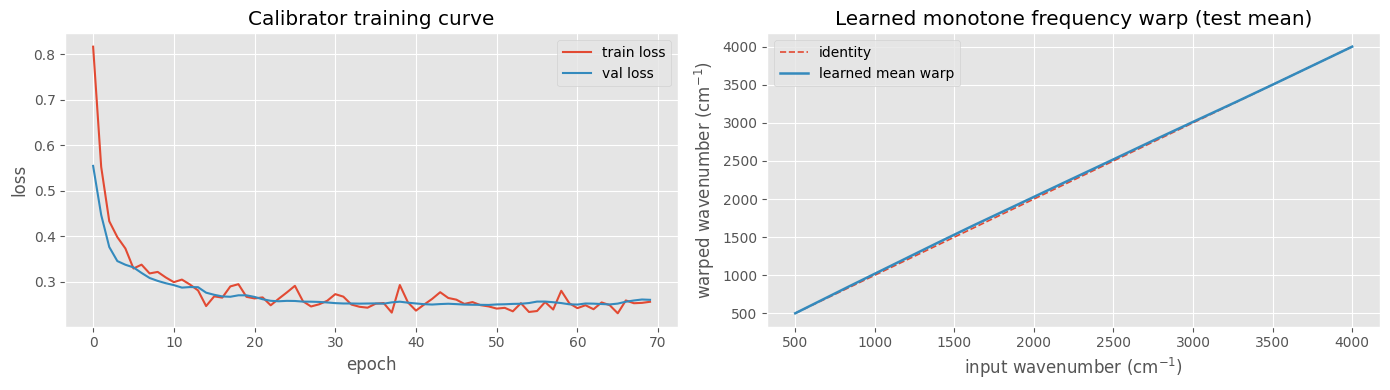

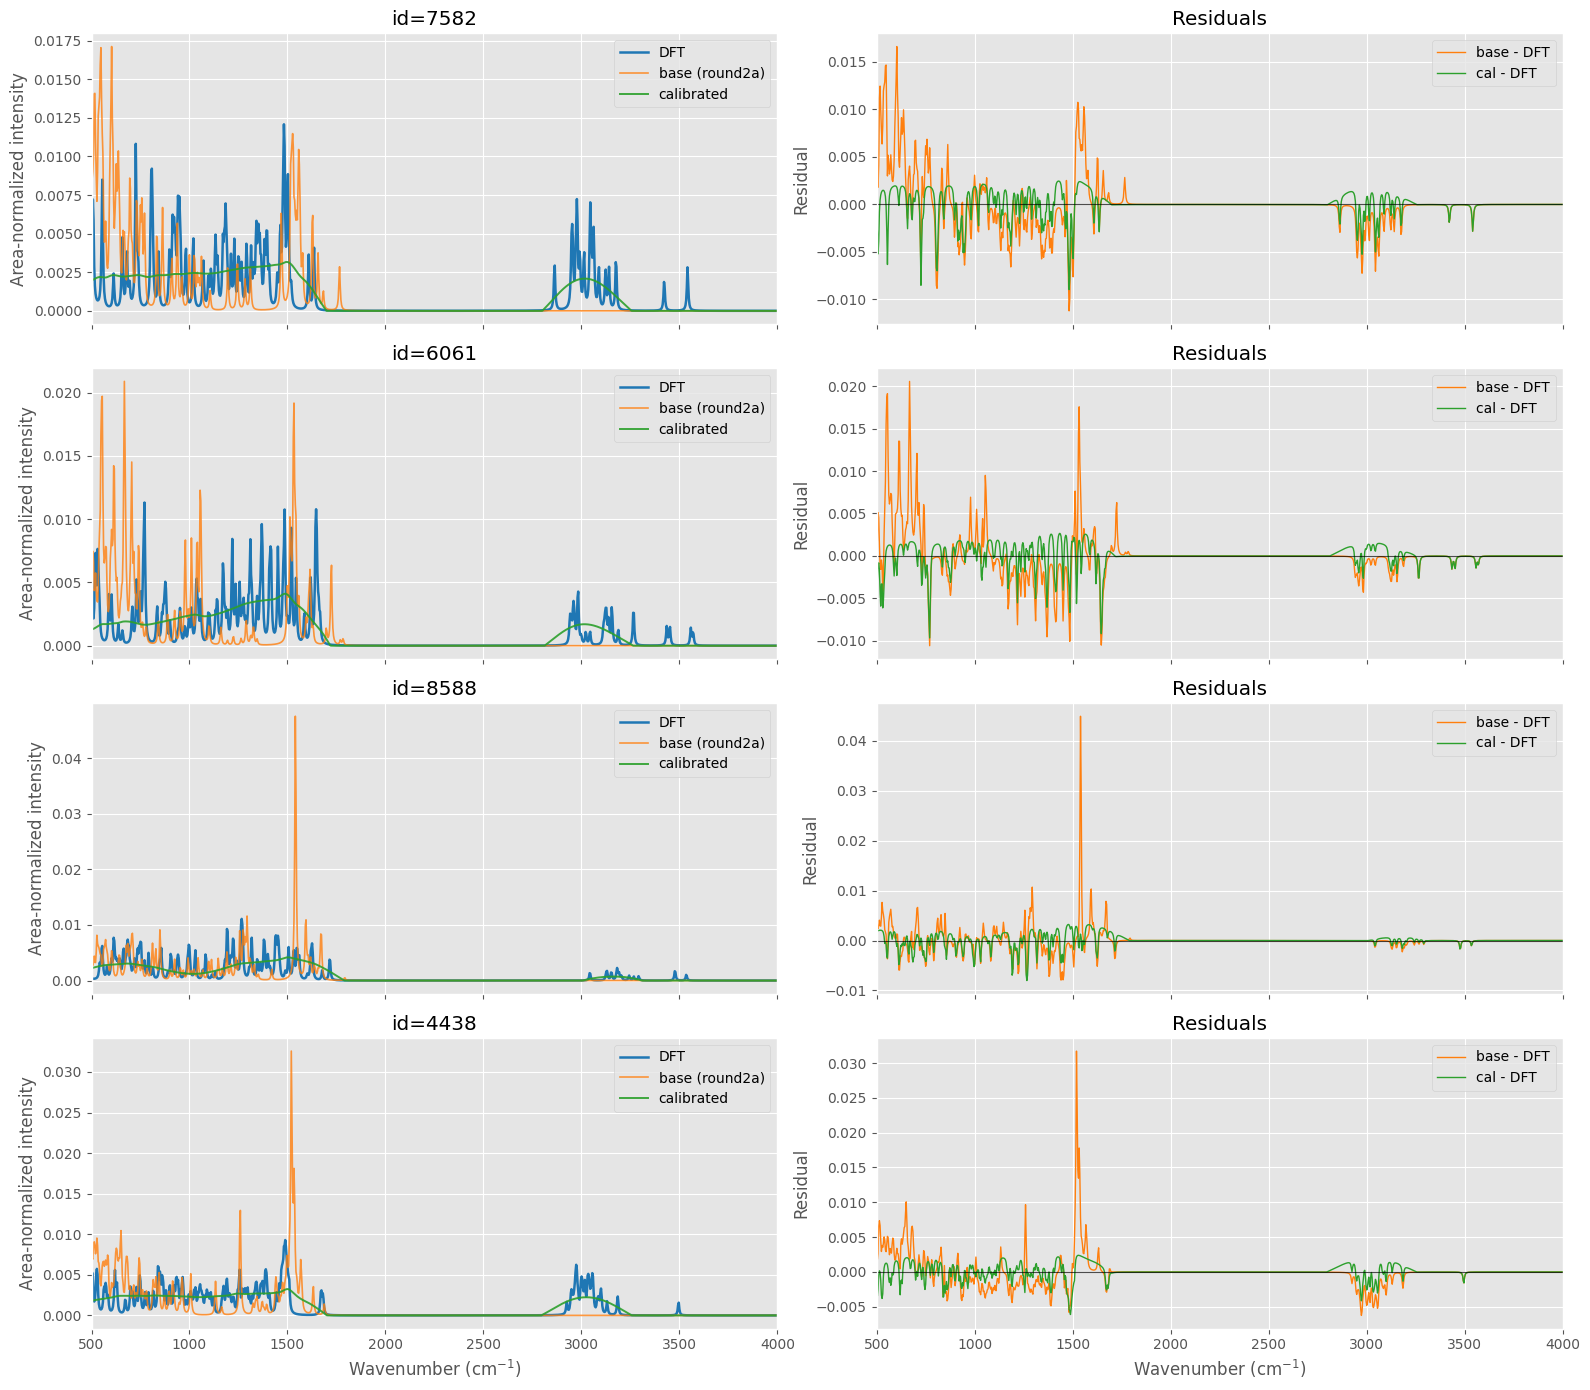

In [23]:
# Phase 3A.2 - Train monotone warp + learned broadening + amplitude calibrator (MPS-first + Fréchet eval)
import math
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

if 'phase3_data' not in globals():
    raise RuntimeError('Run Phase 3A.1 data prep cell first.')

P3_SEED = 2026
P3_EPOCHS = 80
P3_BATCH_SIZE = 64
P3_LR = 2e-3
P3_WEIGHT_DECAY = 1e-4
P3_PATIENCE = 20
P3_KNOTS = 14
P3_BASIS = 28
P3_KERNEL_RADIUS = 32
P3_BOOT_ITERS = 1000
P3_FRECHET_DOWNSAMPLE = 16

torch.manual_seed(P3_SEED)
np.random.seed(P3_SEED)

x_base = phase3_data['x_base']
y_true = phase3_data['y_true']
meta_raw = phase3_data['meta_raw']
ids_all = phase3_data['ids']
smiles_all = phase3_data['smiles']
splits = phase3_data['splits']

train_idx = np.asarray(splits['train'], dtype=np.int64)
val_idx = np.asarray(splits['val'], dtype=np.int64)
test_idx = np.asarray(splits['test'], dtype=np.int64)

meta_mu = meta_raw[train_idx].mean(axis=0, keepdims=True)
meta_sd = meta_raw[train_idx].std(axis=0, keepdims=True)
meta_sd = np.where(meta_sd < 1e-6, 1.0, meta_sd)
meta_norm = (meta_raw - meta_mu) / meta_sd


def _to_t(arr):
    return torch.tensor(arr, dtype=torch.float32)


class SpectraDataset(Dataset):
    def __init__(self, x, y, m, idx):
        self.x = _to_t(x[idx])
        self.y = _to_t(y[idx])
        self.m = _to_t(m[idx])
        self.idx = np.asarray(idx, dtype=np.int64)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i], self.y[i], self.m[i], int(self.idx[i])


class MonotoneCalibrator(nn.Module):
    def __init__(self, grid_size, meta_dim, n_knots=12, n_basis=24, kernel_radius=24):
        super().__init__()
        self.grid_size = int(grid_size)
        self.n_knots = int(n_knots)
        self.kernel_radius = int(kernel_radius)

        hidden = 96
        self.meta_net = nn.Sequential(
            nn.Linear(meta_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
        )

        self.global_warp_raw = nn.Parameter(torch.zeros(self.n_knots - 1))
        self.warp_head = nn.Linear(hidden, self.n_knots - 1)
        self.kernel_head = nn.Linear(hidden, 3)  # sigma, gamma, eta
        self.gain_head = nn.Linear(hidden, n_basis)
        self.bias_head = nn.Linear(hidden, n_basis)

        x_norm = torch.linspace(0.0, 1.0, self.grid_size)
        knot_x = torch.linspace(0.0, 1.0, self.n_knots)
        offsets = torch.arange(-self.kernel_radius, self.kernel_radius + 1, dtype=torch.float32)

        centers = torch.linspace(0.0, 1.0, n_basis)
        basis_width = 1.0 / max(2.0, n_basis - 1)
        basis = torch.exp(-0.5 * ((x_norm[None, :] - centers[:, None]) / basis_width) ** 2)

        self.register_buffer('x_norm', x_norm)
        self.register_buffer('knot_x', knot_x)
        self.register_buffer('offsets', offsets)
        self.register_buffer('basis', basis)

    def _piecewise_warp(self, y_knots):
        B = y_knots.shape[0]
        seg = torch.clamp((self.x_norm * (self.n_knots - 1)).long(), 0, self.n_knots - 2)
        x0 = self.knot_x[seg]
        x1 = self.knot_x[seg + 1]
        t = ((self.x_norm - x0) / (x1 - x0 + 1e-8)).unsqueeze(0).expand(B, -1)

        y0 = y_knots[:, seg]
        y1 = y_knots[:, seg + 1]
        warp = y0 + t * (y1 - y0)
        return torch.clamp(warp, 0.0, 1.0)

    def _resample(self, y, warp):
        idxf = warp * (self.grid_size - 1)
        i0 = torch.floor(idxf).long().clamp(0, self.grid_size - 1)
        i1 = (i0 + 1).clamp(0, self.grid_size - 1)
        a = idxf - i0.float()

        y0 = torch.gather(y, dim=1, index=i0)
        y1 = torch.gather(y, dim=1, index=i1)
        return y0 + a * (y1 - y0)

    def _pseudovoigt_blur(self, y, sigma, gamma, eta):
        B, L = y.shape
        offs = self.offsets.unsqueeze(0)
        sigma = sigma.unsqueeze(1).clamp_min(1e-3)
        gamma = gamma.unsqueeze(1).clamp_min(1e-3)
        eta = eta.unsqueeze(1).clamp(0.0, 1.0)

        gauss = torch.exp(-0.5 * (offs / sigma) ** 2) / (sigma * math.sqrt(2.0 * math.pi))
        lorentz = (gamma / math.pi) / (offs ** 2 + gamma ** 2)
        kernel = (1.0 - eta) * gauss + eta * lorentz
        kernel = kernel / (kernel.sum(dim=1, keepdim=True) + 1e-8)

        pad = self.kernel_radius
        y_pad = F.pad(y.unsqueeze(1), (pad, pad), mode='reflect')

        # --- THE SPEED FIX: Grouped Convolution ---
        # Reshape inputs so PyTorch sees 1 batch with (B) channels
        y_pad_g = y_pad.view(1, B, -1)       # Shape: (1, B, L_pad)
        kernel_g = kernel.view(B, 1, -1)     # Shape: (B, 1, kernel_size)
        
        # Apply conv1d with groups=B (processes all unique kernels instantly)
        out = F.conv1d(y_pad_g, kernel_g, groups=B)
        
        return out.view(B, L)                # Reshape back to (B, L)

    def forward(self, y_base, meta):
        h = self.meta_net(meta)

        raw = self.global_warp_raw.unsqueeze(0) + 0.20 * self.warp_head(h)
        inc = F.softplus(raw) + 1e-4
        yk = torch.cat([torch.zeros(inc.shape[0], 1, device=inc.device), torch.cumsum(inc, dim=1)], dim=1)
        yk = yk / (yk[:, -1:] + 1e-8)

        warp = self._piecewise_warp(yk)
        y_warp = self._resample(y_base, warp)

        k_raw = self.kernel_head(h)
        sigma = 2.0 + 20.0 * torch.sigmoid(k_raw[:, 0])
        gamma = 1.0 + 18.0 * torch.sigmoid(k_raw[:, 1])
        eta = torch.sigmoid(k_raw[:, 2])
        y_blur = self._pseudovoigt_blur(y_warp, sigma=sigma, gamma=gamma, eta=eta)

        gain_coeff = self.gain_head(h)
        bias_coeff = self.bias_head(h)

        gain_field = torch.matmul(gain_coeff, self.basis)
        bias_field = torch.matmul(bias_coeff, self.basis)

        gain = 0.5 + F.softplus(gain_field)
        bias = 0.08 * torch.tanh(bias_field)

        y_amp = torch.relu(gain * y_blur + bias)
        y_out = y_amp / (y_amp.sum(dim=1, keepdim=True) + 1e-8)

        aux = {
            'warp': warp,
            'id_grid': self.x_norm.unsqueeze(0).expand_as(warp),
            'gain': gain,
            'sigma': sigma,
            'gamma': gamma,
            'eta': eta,
        }
        return y_out, aux


def calibrator_loss(pred, target, aux):
    pred = pred / (pred.sum(dim=1, keepdim=True) + 1e-8)
    target = target / (target.sum(dim=1, keepdim=True) + 1e-8)

    mse = F.mse_loss(pred, target)
    cos = 1.0 - F.cosine_similarity(pred, target, dim=1).mean()
    emd = torch.mean(torch.abs(torch.cumsum(pred, dim=1) - torch.cumsum(target, dim=1)))

    warp_reg = ((aux['warp'] - aux['id_grid']) ** 2).mean()
    gain_reg = ((aux['gain'] - 1.0) ** 2).mean()

    loss = 2.0 * emd + 1.0 * cos + 0.5 * mse + 0.12 * warp_reg + 0.03 * gain_reg

    items = {
        'loss': float(loss.detach().cpu().item()),
        'emd': float(emd.detach().cpu().item()),
        'cos': float(cos.detach().cpu().item()),
        'mse': float(mse.detach().cpu().item()),
        'warp_reg': float(warp_reg.detach().cpu().item()),
    }
    return loss, items


def _curve_points_for_frechet(y, downsample=16):
    y = np.asarray(y, dtype=np.float64)
    x = np.linspace(0.0, 1.0, y.shape[0], dtype=np.float64)
    step = max(1, int(downsample))
    idx = np.arange(0, y.shape[0], step, dtype=np.int64)
    if idx[-1] != y.shape[0] - 1:
        idx = np.append(idx, y.shape[0] - 1)
    return np.stack([x[idx], y[idx]], axis=1)


def _discrete_frechet(curve_a, curve_b):
    P = np.asarray(curve_a, dtype=np.float64)
    Q = np.asarray(curve_b, dtype=np.float64)
    n, m = P.shape[0], Q.shape[0]
    if n == 0 or m == 0:
        return np.nan

    ca = np.full((n, m), np.nan, dtype=np.float64)

    def d(i, j):
        return np.linalg.norm(P[i] - Q[j])

    ca[0, 0] = d(0, 0)
    for i in range(1, n):
        ca[i, 0] = max(ca[i - 1, 0], d(i, 0))
    for j in range(1, m):
        ca[0, j] = max(ca[0, j - 1], d(0, j))

    for i in range(1, n):
        for j in range(1, m):
            ca[i, j] = max(min(ca[i - 1, j], ca[i - 1, j - 1], ca[i, j - 1]), d(i, j))
    return float(ca[n - 1, m - 1])


def _batch_metrics_np(y_pred, y_true, frechet_downsample=16):
    eps = 1e-12
    yp = np.clip(np.asarray(y_pred, dtype=np.float64), 0.0, None)
    yt = np.clip(np.asarray(y_true, dtype=np.float64), 0.0, None)

    yp = yp / (yp.sum(axis=1, keepdims=True) + eps)
    yt = yt / (yt.sum(axis=1, keepdims=True) + eps)

    rmse = np.sqrt(np.mean((yp - yt) ** 2, axis=1))
    cos = np.sum(yp * yt, axis=1) / ((np.linalg.norm(yp, axis=1) * np.linalg.norm(yt, axis=1)) + eps)
    emd = np.mean(np.abs(np.cumsum(yp, axis=1) - np.cumsum(yt, axis=1)), axis=1)

    frechet = np.full(yp.shape[0], np.nan, dtype=np.float64)
    for i in range(yp.shape[0]):
        frechet[i] = _discrete_frechet(
            _curve_points_for_frechet(yp[i], downsample=frechet_downsample),
            _curve_points_for_frechet(yt[i], downsample=frechet_downsample),
        )

    return {'rmse': rmse, 'cosine': cos, 'emd': emd, 'frechet': frechet}


def _bootstrap_ci(values, n_boot=1000, seed=123):
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {'median': np.nan, 'ci_low': np.nan, 'ci_high': np.nan}

    rng = np.random.default_rng(seed)
    n = arr.size
    boots = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        sample = rng.choice(arr, size=n, replace=True)
        boots[i] = np.median(sample)
    lo, hi = np.quantile(boots, [0.025, 0.975])
    return {'median': float(np.median(arr)), 'ci_low': float(lo), 'ci_high': float(hi)}


train_ds = SpectraDataset(x_base, y_true, meta_norm, train_idx)
val_ds = SpectraDataset(x_base, y_true, meta_norm, val_idx)
test_ds = SpectraDataset(x_base, y_true, meta_norm, test_idx)

train_loader = DataLoader(train_ds, batch_size=min(P3_BATCH_SIZE, len(train_ds)), shuffle=True)
val_loader = DataLoader(val_ds, batch_size=min(P3_BATCH_SIZE, max(1, len(val_ds))), shuffle=False)

if torch.backends.mps.is_available():
    device_cal = torch.device('mps')
elif torch.cuda.is_available():
    device_cal = torch.device('cuda')
else:
    device_cal = torch.device('cpu')
print('Calibrator device:', device_cal)

model_cal = MonotoneCalibrator(
    grid_size=x_base.shape[1],
    meta_dim=meta_norm.shape[1],
    n_knots=P3_KNOTS,
    n_basis=P3_BASIS,
    kernel_radius=P3_KERNEL_RADIUS,
).to(device_cal)

optimizer = torch.optim.AdamW(model_cal.parameters(), lr=P3_LR, weight_decay=P3_WEIGHT_DECAY)

history = {'train_loss': [], 'val_loss': [], 'val_emd': [], 'val_cos': []}
best_state = None
best_val = float('inf')
wait = 0

for epoch in range(1, P3_EPOCHS + 1):
    model_cal.train()
    train_losses = []

    for xb, yb, mb, _ in train_loader:
        xb = xb.to(device_cal)
        yb = yb.to(device_cal)
        mb = mb.to(device_cal)

        optimizer.zero_grad(set_to_none=True)
        pred, aux = model_cal(xb, mb)
        loss, items = calibrator_loss(pred, yb, aux)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_cal.parameters(), max_norm=2.0)
        optimizer.step()
        train_losses.append(items['loss'])

    model_cal.eval()
    val_losses = []
    val_emds = []
    val_coss = []
    with torch.no_grad():
        for xb, yb, mb, _ in val_loader:
            xb = xb.to(device_cal)
            yb = yb.to(device_cal)
            mb = mb.to(device_cal)

            pred, aux = model_cal(xb, mb)
            _, items = calibrator_loss(pred, yb, aux)
            val_losses.append(items['loss'])
            val_emds.append(items['emd'])
            val_coss.append(items['cos'])

    tr = float(np.mean(train_losses)) if len(train_losses) else np.nan
    va = float(np.mean(val_losses)) if len(val_losses) else np.nan
    ve = float(np.mean(val_emds)) if len(val_emds) else np.nan
    vc = float(np.mean(val_coss)) if len(val_coss) else np.nan

    history['train_loss'].append(tr)
    history['val_loss'].append(va)
    history['val_emd'].append(ve)
    history['val_cos'].append(vc)

    if va < best_val - 1e-5:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model_cal.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | train={tr:.6f} val={va:.6f} val_emd={ve:.6f} val_cos={vc:.6f}')

    if wait >= P3_PATIENCE:
        print(f'Early stop at epoch {epoch} (patience={P3_PATIENCE})')
        break

if best_state is not None:
    model_cal.load_state_dict(best_state)


def _predict_split(ds):
    loader = DataLoader(ds, batch_size=min(P3_BATCH_SIZE, max(1, len(ds))), shuffle=False)
    model_cal.eval()
    out_pred, out_base, out_true, out_idx, out_warp = [], [], [], [], []

    with torch.no_grad():
        for xb, yb, mb, ii in loader:
            pred, aux = model_cal(xb.to(device_cal), mb.to(device_cal))
            out_pred.append(pred.detach().cpu().numpy())
            out_base.append(xb.numpy())
            out_true.append(yb.numpy())
            out_idx.append(ii.numpy())
            out_warp.append(aux['warp'].detach().cpu().numpy())

    return {
        'pred': np.concatenate(out_pred, axis=0),
        'base': np.concatenate(out_base, axis=0),
        'true': np.concatenate(out_true, axis=0),
        'idx': np.concatenate(out_idx, axis=0),
        'warp': np.concatenate(out_warp, axis=0),
    }


train_out = _predict_split(train_ds)
val_out = _predict_split(val_ds)
test_out = _predict_split(test_ds)

base_test_m = _batch_metrics_np(test_out['base'], test_out['true'], frechet_downsample=P3_FRECHET_DOWNSAMPLE)
cal_test_m = _batch_metrics_np(test_out['pred'], test_out['true'], frechet_downsample=P3_FRECHET_DOWNSAMPLE)

rows = []
for i in range(test_out['pred'].shape[0]):
    rid = int(ids_all[test_out['idx'][i]])
    rows.append({
        'id': rid,
        'rmse_base': float(base_test_m['rmse'][i]),
        'rmse_cal': float(cal_test_m['rmse'][i]),
        'cos_base': float(base_test_m['cosine'][i]),
        'cos_cal': float(cal_test_m['cosine'][i]),
        'emd_base': float(base_test_m['emd'][i]),
        'emd_cal': float(cal_test_m['emd'][i]),
        'frechet_base': float(base_test_m['frechet'][i]),
        'frechet_cal': float(cal_test_m['frechet'][i]),
    })

df_cal_test = pd.DataFrame(rows)
df_cal_test['delta_rmse_base_minus_cal'] = df_cal_test['rmse_base'] - df_cal_test['rmse_cal']
df_cal_test['delta_emd_base_minus_cal'] = df_cal_test['emd_base'] - df_cal_test['emd_cal']
df_cal_test['delta_cos_cal_minus_base'] = df_cal_test['cos_cal'] - df_cal_test['cos_base']
df_cal_test['delta_frechet_base_minus_cal'] = df_cal_test['frechet_base'] - df_cal_test['frechet_cal']

display(df_cal_test.sort_values('delta_frechet_base_minus_cal', ascending=False).reset_index(drop=True))

summary_tbl = pd.DataFrame([
    {
        'metric': 'rmse',
        'base_median': float(np.median(base_test_m['rmse'])),
        'cal_median': float(np.median(cal_test_m['rmse'])),
        'base_ci': _bootstrap_ci(base_test_m['rmse'], n_boot=P3_BOOT_ITERS, seed=111),
        'cal_ci': _bootstrap_ci(cal_test_m['rmse'], n_boot=P3_BOOT_ITERS, seed=112),
    },
    {
        'metric': 'emd',
        'base_median': float(np.median(base_test_m['emd'])),
        'cal_median': float(np.median(cal_test_m['emd'])),
        'base_ci': _bootstrap_ci(base_test_m['emd'], n_boot=P3_BOOT_ITERS, seed=113),
        'cal_ci': _bootstrap_ci(cal_test_m['emd'], n_boot=P3_BOOT_ITERS, seed=114),
    },
    {
        'metric': 'cosine',
        'base_median': float(np.median(base_test_m['cosine'])),
        'cal_median': float(np.median(cal_test_m['cosine'])),
        'base_ci': _bootstrap_ci(base_test_m['cosine'], n_boot=P3_BOOT_ITERS, seed=115),
        'cal_ci': _bootstrap_ci(cal_test_m['cosine'], n_boot=P3_BOOT_ITERS, seed=116),
    },
    {
        'metric': 'frechet',
        'base_median': float(np.median(base_test_m['frechet'])),
        'cal_median': float(np.median(cal_test_m['frechet'])),
        'base_ci': _bootstrap_ci(base_test_m['frechet'], n_boot=P3_BOOT_ITERS, seed=117),
        'cal_ci': _bootstrap_ci(cal_test_m['frechet'], n_boot=P3_BOOT_ITERS, seed=118),
    },
])

display(summary_tbl)
print('Base phase used for calibrator:', phase3_data['base_phase'])

# training curves + warp summary
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history['train_loss'], label='train loss')
ax[0].plot(history['val_loss'], label='val loss')
ax[0].set_title('Calibrator training curve')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()

mean_warp = test_out['warp'].mean(axis=0)
ax[1].plot(x_grid_cal, x_grid_cal, '--', lw=1.2, label='identity')
ax[1].plot(x_grid_cal, 500.0 + mean_warp * (4000.0 - 500.0), lw=1.8, label='learned mean warp')
ax[1].set_title('Learned monotone frequency warp (test mean)')
ax[1].set_xlabel('input wavenumber (cm$^{-1}$)')
ax[1].set_ylabel('warped wavenumber (cm$^{-1}$)')
ax[1].legend()

plt.tight_layout()
plt.show()

# before/after overlays on a few test samples
show_n = min(4, test_out['pred'].shape[0])
if show_n > 0:
    fig, axes = plt.subplots(show_n, 2, figsize=(16, 3.5 * show_n), sharex=True)
    if show_n == 1:
        axes = np.array([axes])

    for i in range(show_n):
        rid = int(ids_all[test_out['idx'][i]])
        y_true_i = test_out['true'][i]
        y_base_i = test_out['base'][i]
        y_cal_i = test_out['pred'][i]

        axes[i, 0].plot(x_grid_cal, y_true_i, lw=1.8, color='tab:blue', label='DFT')
        axes[i, 0].plot(x_grid_cal, y_base_i, lw=1.2, color='tab:orange', alpha=0.8, label=f'base ({phase3_data["base_phase"]})')
        axes[i, 0].plot(x_grid_cal, y_cal_i, lw=1.4, color='tab:green', alpha=0.9, label='calibrated')
        axes[i, 0].set_xlim(500, 4000)
        axes[i, 0].set_ylabel('Area-normalized intensity')
        axes[i, 0].set_title(f'id={rid}')
        axes[i, 0].legend(loc='upper right')

        axes[i, 1].plot(x_grid_cal, y_base_i - y_true_i, lw=1.0, color='tab:orange', label='base - DFT')
        axes[i, 1].plot(x_grid_cal, y_cal_i - y_true_i, lw=1.0, color='tab:green', label='cal - DFT')
        axes[i, 1].axhline(0.0, color='k', lw=0.8, alpha=0.7)
        axes[i, 1].set_xlim(500, 4000)
        axes[i, 1].set_ylabel('Residual')
        axes[i, 1].set_title('Residuals')
        axes[i, 1].legend(loc='upper right')

    axes[-1, 0].set_xlabel('Wavenumber (cm$^{-1}$)')
    axes[-1, 1].set_xlabel('Wavenumber (cm$^{-1}$)')
    plt.tight_layout()
    plt.show()
